# Penerapan PCA pada Industri Otomotif

## 1. OVERVIEW DATASET
Dataset ini memberikan informasi terperinci tentang pasar mobil di Australia, termasuk atribut seperti kode mobil, nama mobil, harga mobil, merek mobil, tahun model mobil, jenis gearbox, jenis desain, jenis bahan bakar, kondisi mobil, jarak tempuh, kapasitas mesin, warna mobil, dan kapasitas tempat duduk. Data ini merupakan sumber data yang kaya yang membantu mengeksplorasi tren dan dinamika di pasar mobil Australia, mendukung analisis dan pengambilan keputusan dalam industri otomotif.

## 2. Tujuan Analisis
    Mengidentifikasi faktor-faktor utama yang memengaruhi harga mobil untuk menawarkan harga atau rekomendasi pembelian.
    Identifikasi model dan segmen pasar yang populer berdasarkan karakteristik seperti tipe bodi, merek, dan model mobil.
    Studi pengaruh jarak tempuh dan kondisi mobil terhadap harga untuk mengidentifikasi ketergantungan.
    Pengembangan model untuk memprediksi harga mobil berdasarkan data historis dan karakteristik mobil.

## 3. Library

In [2]:
# Untuk analisis data dan processing
import pandas as pd
import numpy as np
import warnings

# Untuk visualisasi data
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Untuk Mechine Learning dan Statistik
from sklearn.cluster import KMeans
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from yellowbrick.cluster import KElbowVisualizer
import scipy

# Untuk Operasi Matematika
from math import factorial, comb

## 4. Load Data

In [3]:
df = pd.read_csv("cars_info.csv")
df.head()

,ID,Name,Price,Brand,Model,Variant,Series,Year,Kilometers,Type,Gearbox,Fuel,Status,CC,Color,Seating Capacity
0,11530130,2010 Toyota Rukus Build 2 AZE151R,9999,Toyota,Rukus,Build 2,AZE151R,2010,263000,Wagon,Automatic,Unleaded Petrol,Used,2362,Grey,5
1,12190570,2021 Mercedes-Benz V 250 D Avantgarde MWB 447 ...,117990,Mercedes-Benz,V,250 D Avantgarde MWB,447 MY21,2021,19,Wagon,Automatic,Diesel,New In Stock,2143,Black,7
2,12321855,2021 Mercedes-Benz Valente 116 CDI MWB RWD 447...,79990,Mercedes-Benz,Valente,116 CDI MWB RWD,447 MY21,2021,24,Wagon,Automatic,Diesel,New In Stock,2143,Black,8
3,12346971,2010 Mercedes-Benz E250 CDI Avantgarde 207,34990,Mercedes-Benz,E250,CDI Avantgarde,207,2010,120579,Cabriolet,Automatic,Diesel,Used,2143,Black,4
4,12363884,2016 Holden Cruze CD JH MY16,15990,Holden,Cruze,CD,JH MY16,2016,72506,Sportswagon,Automatic,Unleaded Petrol,Used,1796,White,5


### informasi ringkas dan deskripsi statistik mengenai dataset

Untuk analasis data yang efektif, tentunya perlu dilakukan pemeriksaan awal yang mencakup informasi ringkas mengenai dataset, menghitung statistik deskriptif, menganalisis variabel kategorikal, dan memeriksa nilai yang hilang (missing values).

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17048 entries, 0 to 17047
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   ID                17048 non-null  int64 
 1   Name              17048 non-null  object
 2   Price             17048 non-null  int64 
 3   Brand             17048 non-null  object
 4   Model             17048 non-null  object
 5   Variant           17048 non-null  object
 6   Series            17048 non-null  object
 7   Year              17048 non-null  int64 
 8   Kilometers        17048 non-null  int64 
 9   Type              17048 non-null  object
 10  Gearbox           17048 non-null  object
 11  Fuel              17048 non-null  object
 12  Status            17048 non-null  object
 13  CC                17048 non-null  int64 
 14  Color             17048 non-null  object
 15  Seating Capacity  17048 non-null  int64 
dtypes: int64(6), object(10)
memory usage: 2.1+ MB


Informasi umum tentang dataset:
Dataset ini terdiri dari 16 kolom dan 17.048 record.
Tipe data meliputi data numerik (6 kolom bertipe int64) dan string (objek).
Ukuran memori yang ditempati oleh set ini adalah 2,1+ MB.
Tidak ada nilai yang hilang dalam set data, yang menyederhanakan analisis lebih lanjut.

In [6]:
df.describe(include='all')

,ID,Name,Price,Brand,Model,Variant,Series,Year,Kilometers,Type,Gearbox,Fuel,Status,CC,Color,Seating Capacity
count,1.704800e+04,17048,17048.000000,17048,17048,17048,17048,17048.000000,1.704800e+04,17048,17048,17048,17048,17048.000000,17048,17048.000000
unique,NaN,8575,NaN,59,622,2363,2286,NaN,NaN,56,5,7,3,NaN,235,NaN
top,NaN,2018 Nissan X-Trail ST (2WD) T32 Series 2,NaN,Toyota,Ranger,S,MY18,NaN,NaN,Wagon,Automatic,Unleaded Petrol,Used,NaN,White,NaN
freq,NaN,33,NaN,2768,648,287,172,NaN,NaN,7768,14578,7016,16304,NaN,6177,NaN
mean,1.279027e+07,NaN,36777.778038,NaN,NaN,NaN,NaN,2015.481288,1.032314e+05,NaN,NaN,NaN,NaN,2491.830303,NaN,5.115849
std,5.051111e+04,NaN,30305.015328,NaN,NaN,NaN,NaN,4.721591,8.041313e+04,NaN,NaN,NaN,NaN,881.985562,NaN,1.121791
min,1.153013e+07,NaN,1000.000000,NaN,NaN,NaN,NaN,1989.000000,1.000000e+00,NaN,NaN,NaN,NaN,875.000000,NaN,2.000000
25%,1.275715e+07,NaN,18800.000000,NaN,NaN,NaN,NaN,2013.000000,4.450225e+04,NaN,NaN,NaN,NaN,1987.000000,NaN,5.000000
50%,1.280207e+07,NaN,29990.000000,NaN,NaN,NaN,NaN,2016.000000,8.845400e+04,NaN,NaN,NaN,NaN,2354.000000,NaN,5.000000
75%,1.283131e+07,NaN,45990.000000,NaN,NaN,NaN,NaN,2019.000000,1.488735e+05,NaN,NaN,NaN,NaN,2981.000000,NaN,5.000000


Statistik deskriptif:
Bidang Harga, Tahun, Kilometer, CC dan Kapasitas Tempat Duduk memiliki variabilitas yang signifikan, yang penting untuk diperhitungkan ketika membuat model dan analisis.
Harga               : harga minimum adalah 1000, maksimum 999.000, yang mengindikasikan berbagai macam harga mobil.
Tahun               : Mobil bervariasi berdasarkan tahun pembuatannya dari 1989 hingga 2022.
Kilometer           : Satu mobil memiliki jarak tempuh hanya 1 km, dan jarak tempuh maksimum adalah 2,7 juta km, yang         mengindikasikan kemungkinan anomali atau kasus unik.
CC                  : bervariasi dari 875 hingga 7300 sentimeter kubik, yang mengindikasikan perbedaan jenis mesin.
Kapasitas tempat duduk : bervariasi dari 2 hingga 14, yang mencerminkan ketersediaan mobil kecil dan minibus.

### melihat nilai uniq untuk kolom kategorikal

In [7]:
df['Brand'].unique()

array(['Toyota', 'Mercedes-Benz', 'Holden', 'Nissan', 'Ford', 'BMW',
       'Isuzu', 'Hyundai', 'Volkswagen', 'Lexus', 'Mazda', 'Audi',
       'Subaru', 'Mitsubishi', 'Kia', 'Skoda', 'Renault', 'Porsche',
       'Jeep', 'Honda', 'Ssangyong', 'Volvo', 'Land Rover', 'MG',
       'Suzuki', 'Ram', 'Mini', 'Jaguar', 'LDV', 'HSV', 'Alfa Romeo',
       'Aston Martin', 'Hino', 'Chrysler', 'Citroen', 'Infiniti',
       'Peugeot', 'Chevrolet', 'Lamborghini', 'Fiat', 'Bentley', 'Dodge',
       'Haval', 'Great Wall', 'Abarth', 'Foton', 'Genesis', 'GWM', 'FPV',
       'Mitsubishi Fuso', 'Maserati', 'Iveco', 'Mahindra', 'Opel', 'Saab',
       'Chery', 'Smart', 'Proton', 'Cupra'], dtype=object)

Variabel kategorikal:
Kolom `Merek' berisi 57 merek mobil yang unik, yang mungkin memerlukan pengelompokan atau pembuatan variabel boneka untuk model mobil dalam analisis lebih lanjut.

### periksa apakah ada nilai yang null

In [5]:
print(df.isnull().sum())

ID                  0
Name                0
Price               0
Brand               0
Model               0
Variant             0
Series              0
Year                0
Kilometers          0
Type                0
Gearbox             0
Fuel                0
Status              0
CC                  0
Color               0
Seating Capacity    0
dtype: int64


Memeriksa nilai yang hilang:
Tidak ada nilai yang hilang, yang mengindikasikan persiapan data berkualitas tinggi untuk analisis lebih lanjut, sehingga tidak diperlukan penanganan missing values.

## 5. EDA 

### Visualisasi distribusi harga berdasarkan kategori

visualisasi data ini sangat memainkan peran penting dalam menganalisis distribusi harga mobil di berbagai kategori. Penerapan grafik seperti boxplot dan sebagainya, memungkinkan bisnis untuk memperkirakan penyebaran harga, mengidentifikasi emisi, dan memahami bagaimana karakteristik kendaraan seperti merek, jenis bodi, dan jenis bahan bakar.

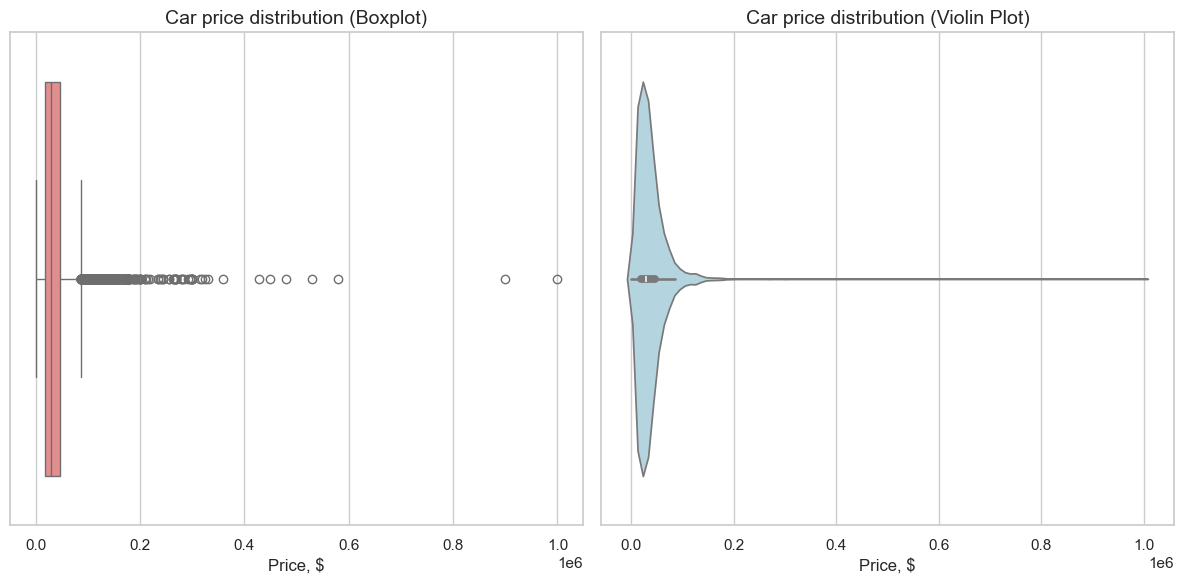

In [8]:
# Customize the style
sns.set(style="whitegrid")

# Membuat Shapenya
plt.figure(figsize=(12, 6))

#1. Boxplot — a box with a mustache
plt.subplot(1, 2, 1)
sns.boxplot(x=df['Price'], color='lightcoral')
plt.title('Car price distribution (Boxplot)', fontsize=14)
plt.xlabel('Price, $', fontsize=12)

# 2. Violin Plot — a violin graph for a more detailed distribution
plt.subplot(1, 2, 2)
sns.violinplot(x=df['Price'], color='lightblue')
plt.title('Car price distribution (Violin Plot)', fontsize=14)
plt.xlabel('Price, $', fontsize=12)

# Displaying both graphs
plt.tight_layout()
plt.show()

Analisis Grafik:

a. Boxplot

- Kecenderungan Sentral: Sebagian besar data terkonsentrasi pada kisaran harga yang lebih rendah (hingga 100.000 dolar), yang mencerminkan tingkat harga rata-rata mobil.
- Pencilan: Banyak titik yang terletak jauh di luar distribusi utama (di atas 200.000 dolar) adalah pencilan, yang mungkin mengindikasikan adanya mobil mewah atau unik dengan harga tinggi dalam sampel.
- Kisaran Harga: Mayoritas data hingga sekitar 100.000 dolar, seperti yang terlihat dari kompresi kotak di bagian bawah plot.
- median : Garis di tengah kotak mewakili harga median, yang juga termasuk dalam kisaran harga yang lebih rendah.

b. Violin Plot

- Bentuk Distribusi: Distribusi harga mobil sangat condong ke kiri, mengonfirmasi keberadaan sejumlah besar mobil dengan harga lebih rendah (hingga 100.000 dolar). Bagian atas biola menyempit, mengindikasikan lebih sedikit mobil dengan kategori harga yang lebih tinggi.
- Detail Distribusi: Distribusi bagian dalam menunjukkan kepadatan data hingga 100.000 dolar, yang mengindikasikan bahwa sebagian besar mobil berada di segmen harga ini.
- Pencilan: Seperti halnya boxplot, pencilan yang signifikan terlihat di ujung kanan plot, yang mengonfirmasi adanya harga yang sangat tinggi.

Kesimpulan:
 Kedua grafik tersebut mengonfirmasi bahwa kumpulan data berisi sejumlah besar mobil dengan harga rendah (hingga 100.000 dolar), sementara mobil mewah atau langka menciptakan pencilan, dengan harga hingga 500.000 dolar. Menganalisis pencilan ini dapat membantu mengelompokkan mobil-mobil tersebut ke dalam beberapa kategori untuk investigasi yang lebih mendalam mengenai faktor-faktor yang memengaruhi harga.

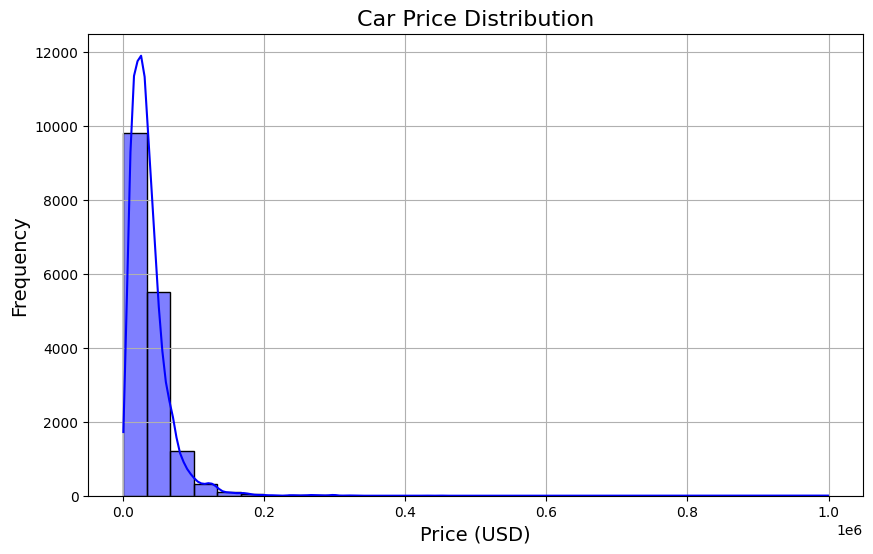

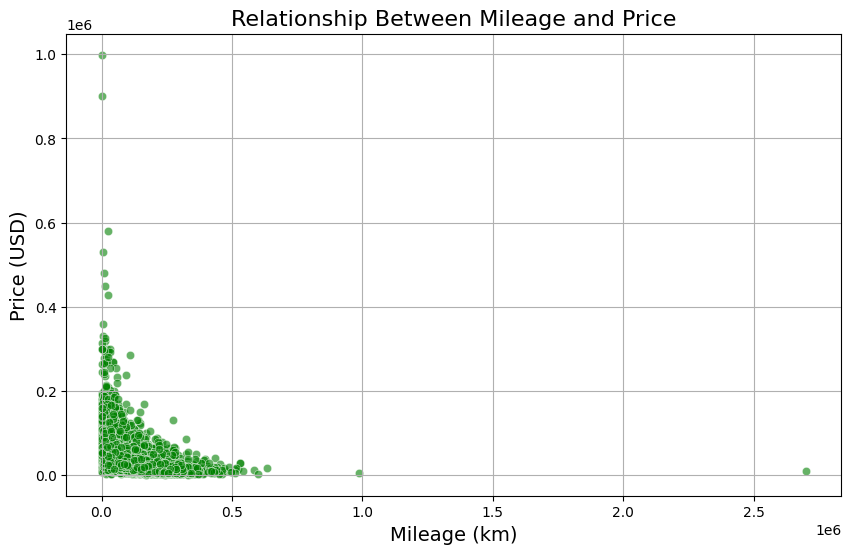

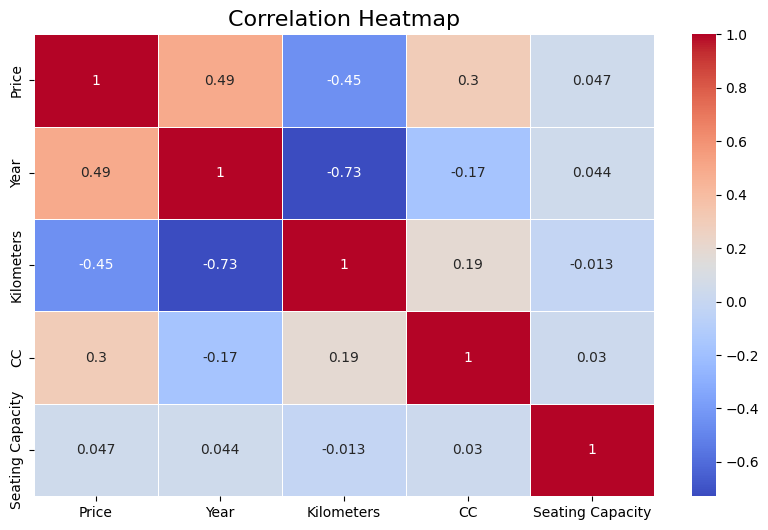

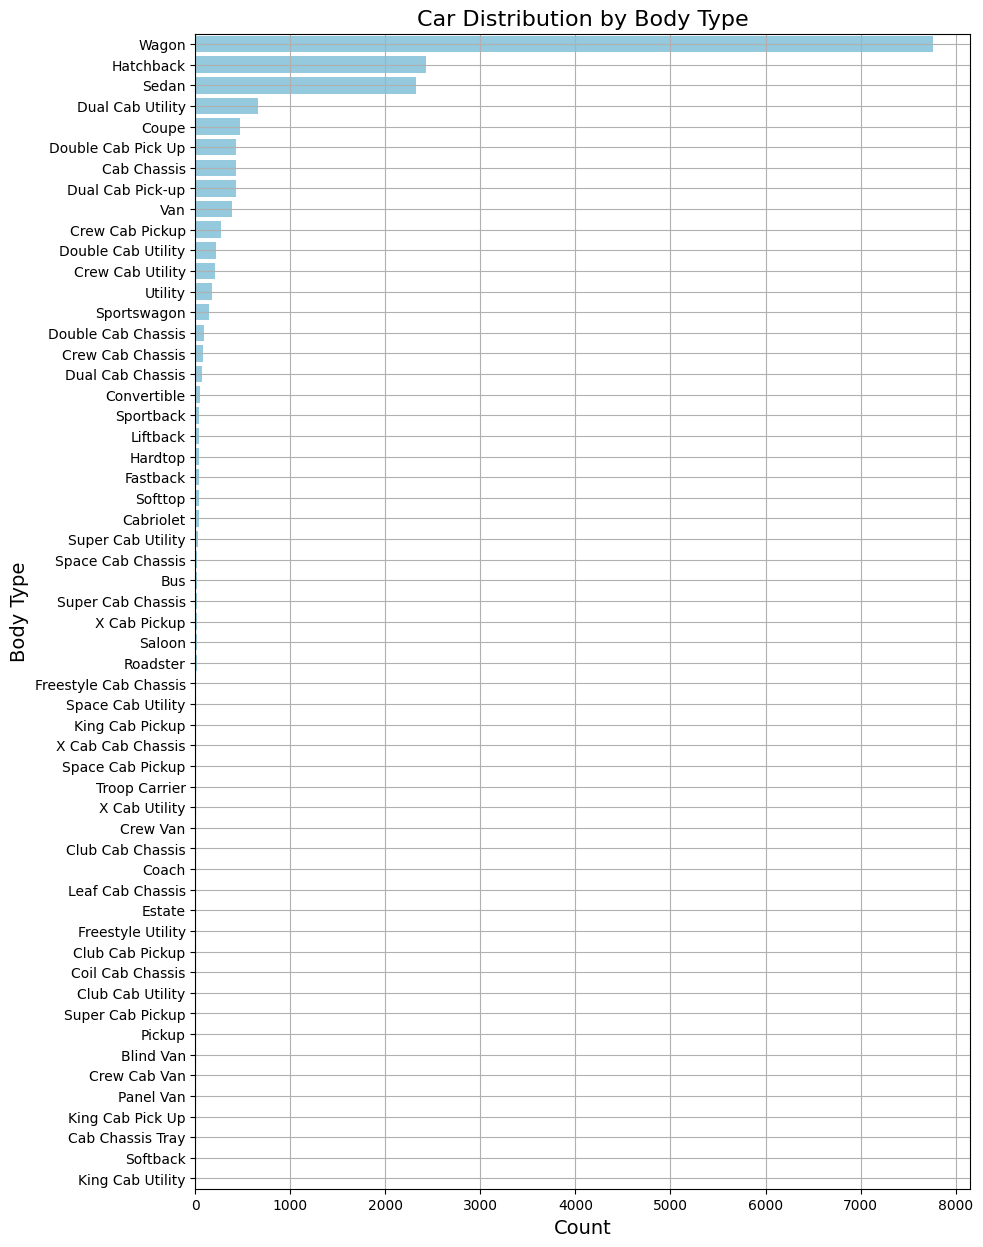

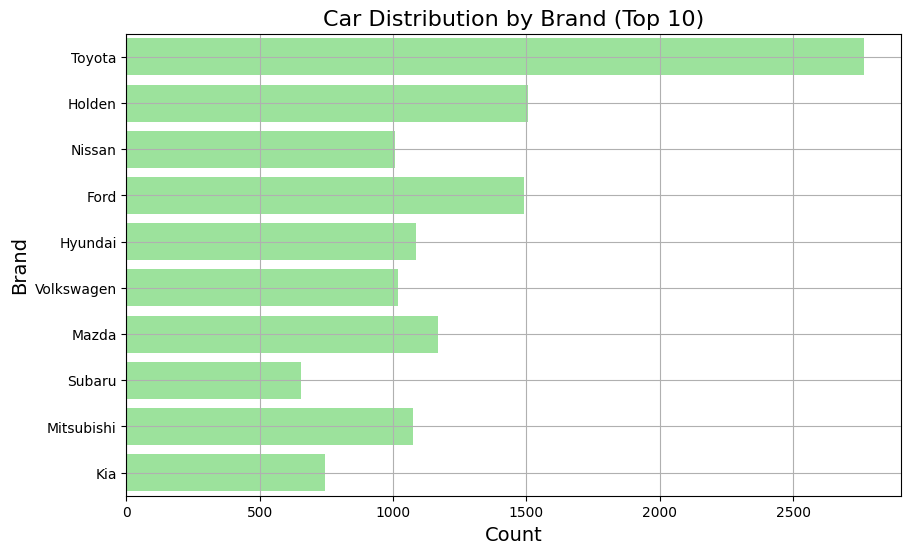

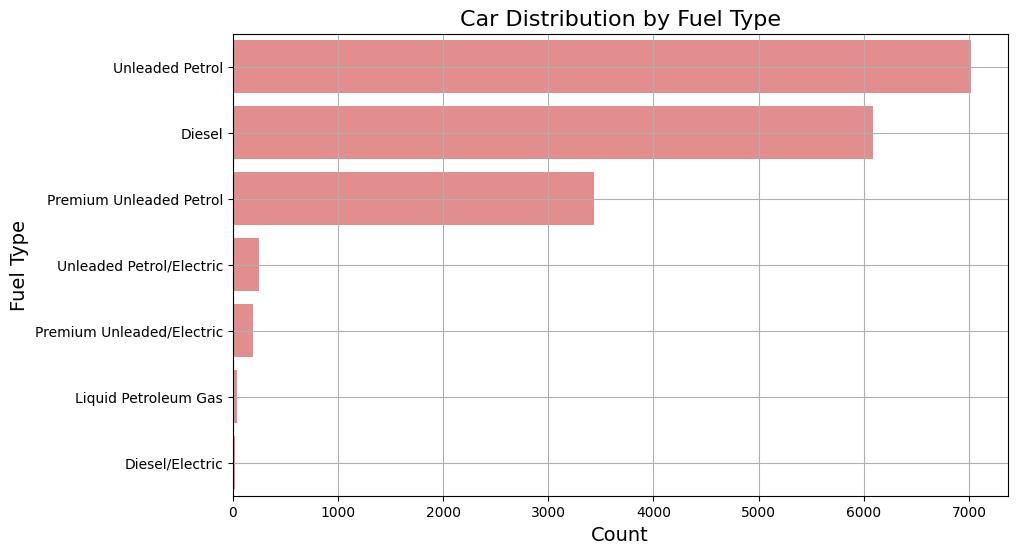

In [9]:
# 1. Histogram for price distribution
plt.figure(figsize=(10, 6))
sns.histplot(df['Price'], bins=30, kde=True, color='blue')
plt.title('Car Price Distribution', fontsize=16)
plt.xlabel('Price (USD)', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.grid(True)
plt.show()

# 2. Scatter plot: price vs mileage (Kilometers)
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Kilometers', y='Price', data=df, color='green', alpha=0.6)
plt.title('Relationship Between Mileage and Price', fontsize=16)
plt.xlabel('Mileage (km)', fontsize=14)
plt.ylabel('Price (USD)', fontsize=14)
plt.grid(True)
plt.show()

# 3. Heatmap of correlations between numerical variables
plt.figure(figsize=(10, 6))
corr_matrix = df[['Price', 'Year', 'Kilometers', 'CC', 'Seating Capacity']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap', fontsize=16)
plt.show()

# 4. Visualization of categorical variables

# 4.1. Body Type
plt.figure(figsize=(10, 15))
sns.countplot(y='Type', data=df, order=df['Type'].value_counts().index, color='skyblue')
plt.title('Car Distribution by Body Type', fontsize=16)
plt.xlabel('Count', fontsize=14)
plt.ylabel('Body Type', fontsize=14)
plt.grid(True)
plt.show()

# 4.2. Brand
plt.figure(figsize=(10, 6))
top_brands = df['Brand'].value_counts().nlargest(10).index  # Top 10 brands
sns.countplot(y='Brand', data=df[df['Brand'].isin(top_brands)], color='lightgreen')
plt.title('Car Distribution by Brand (Top 10)', fontsize=16)
plt.xlabel('Count', fontsize=14)
plt.ylabel('Brand', fontsize=14)
plt.grid(True)
plt.show()

# 4.3. Fuel Type
plt.figure(figsize=(10, 6))
sns.countplot(y='Fuel', data=df, order=df['Fuel'].value_counts().index, color='lightcoral')
plt.title('Car Distribution by Fuel Type', fontsize=16)
plt.xlabel('Count', fontsize=14)
plt.ylabel('Fuel Type', fontsize=14)
plt.grid(True)
plt.show()

Deskripsi plot:

a. Distribusi Harga Mobil :
- Histogram distribusi harga ini menunjukkan bahwa sebagian besar mobil memiliki harga di bawah 100.000 dolar, dengan penurunan frekuensi yang tajam di luar produktifitas.

b. Scatter Plot:
- Menunjukkan korelasi yang negatif antara jarak tempuh dan harga, mobil yang mempunyai jarak tempuh lebih tinggi umumnya memiliki harga yang lebih rendah. Sebaliknya mobil yang mempunyai jarak tempuh lebih rendah cenderung memiliki harga yang jauh lebih luas.

c. Pair Plot:
- Mobil baru cenderung lebih mahal dengan kilometer yang lebih sedikit.
- Harga mobil lebih dipengaruhi oleh tahun dan kilometer.
- Kapasitas kursi tidak terlalu berpengaruh terhadap harga atau spesifikasinya.
- kapasitas mesin sedang berpengaruh ke harga 

d. Distribusi Kategori Mobil:
- Tipe Bodi: Tipe bodi yang paling populer adalah “Wagon”, “Hatchback”, dan “Sedan”, yang mencerminkan preferensi pasar.
- Merek (10 Besar): Merek mobil yang paling umum adalah Toyota, Holden, dan Nissan. Merek-merek ini mendominasi pasar dalam hal jumlah mobil dalam sampel.
- Jenis Bahan Bakar: Jenis bahan bakar utama adalah bensin tanpa timbal dan diesel. Kendaraan listrik dan hibrida mewakili sebagian kecil dari sampel, yang mungkin mencerminkan tren saat ini terhadap ekologi dan pergeseran ke jenis bahan bakar alternatif.

Kesimpulan Umum:
Visualisasi mengkonfirmasi temuan-temuan utama: sebagian besar mobil berharga di bawah 100.000 dolar, dan terdapat korelasi yang kuat antara jarak tempuh, tahun pembuatan, dan harga. Variabel kategorikal (seperti jenis bodi dan jenis bahan bakar) juga berdampak signifikan terhadap distribusi mobil di pasar.

Visualisasi Harga Berdasarkan Kategori

Visualisasi selanjutnya ini, digunakan untuk menganalisis dampak berbagai faktor terhadap harga mobil. Boxplot untuk merek, tipe bodi, dan jenis bahan bakar memungkinkan pengamatan distribusi harga dalam setiap kategori. Histogram Kernel Density Estimation (KDE) membantu memvisualisasikan di mana kisaran harga utama terkonsentrasi untuk setiap kelompok, sehingga memudahkan pengambilan keputusan bisnis.

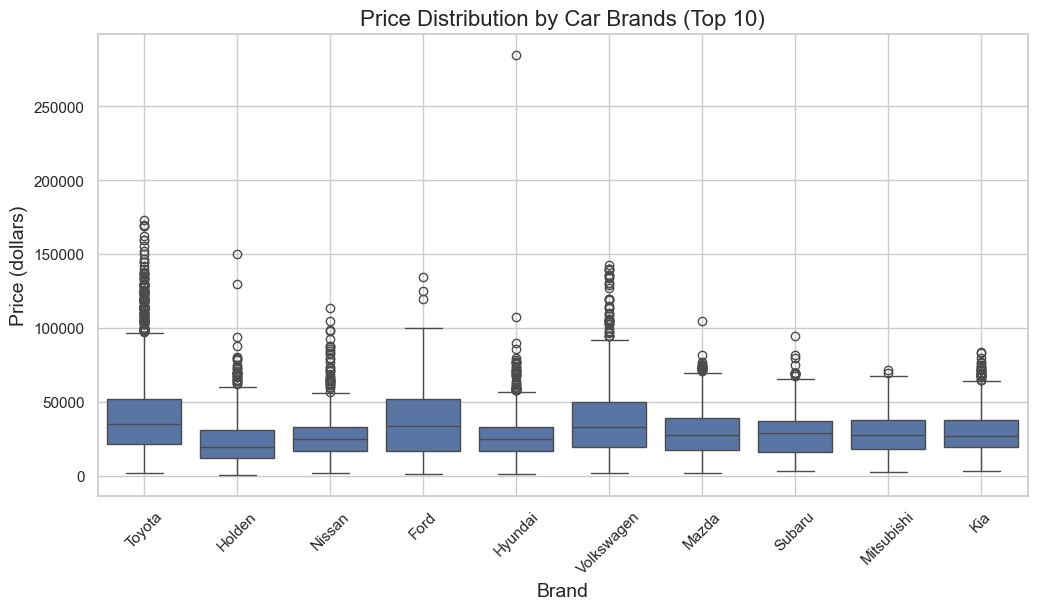

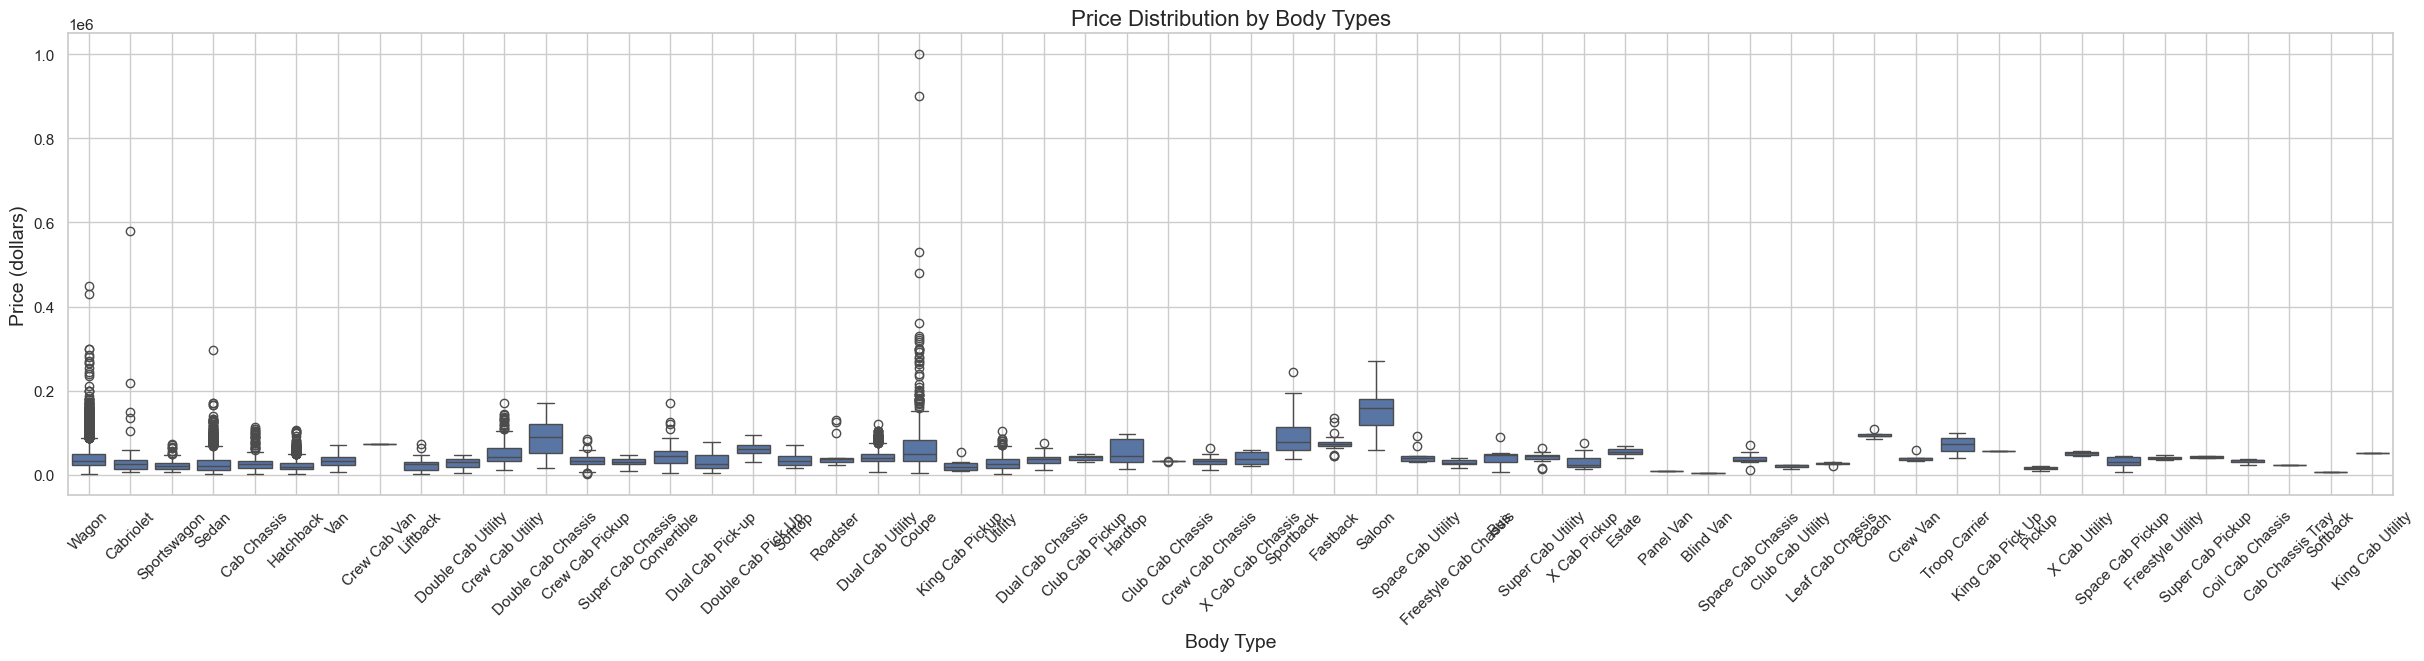

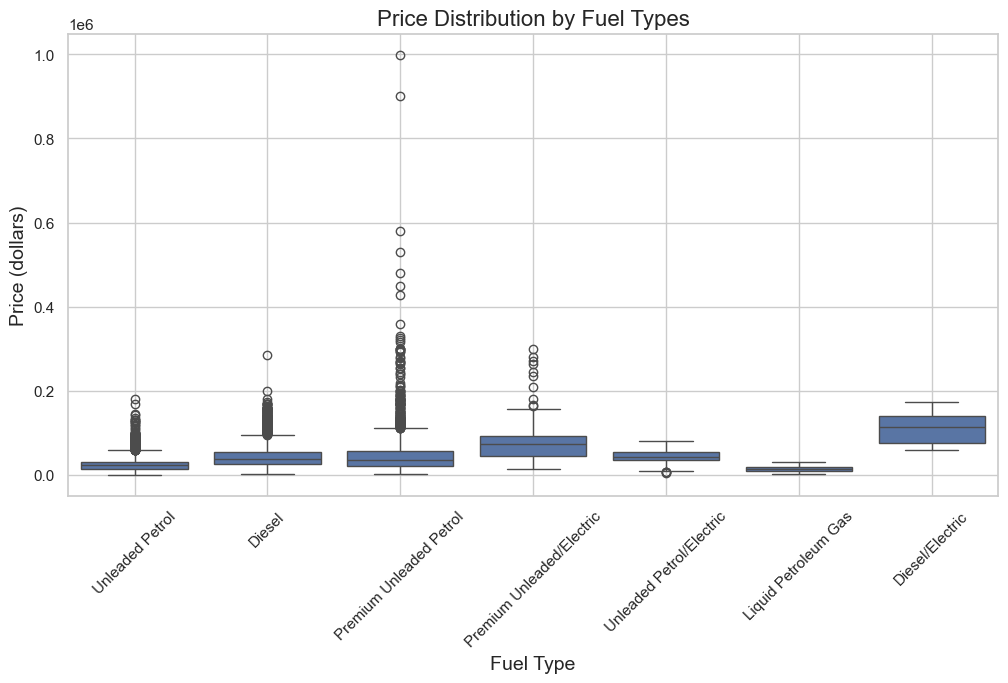

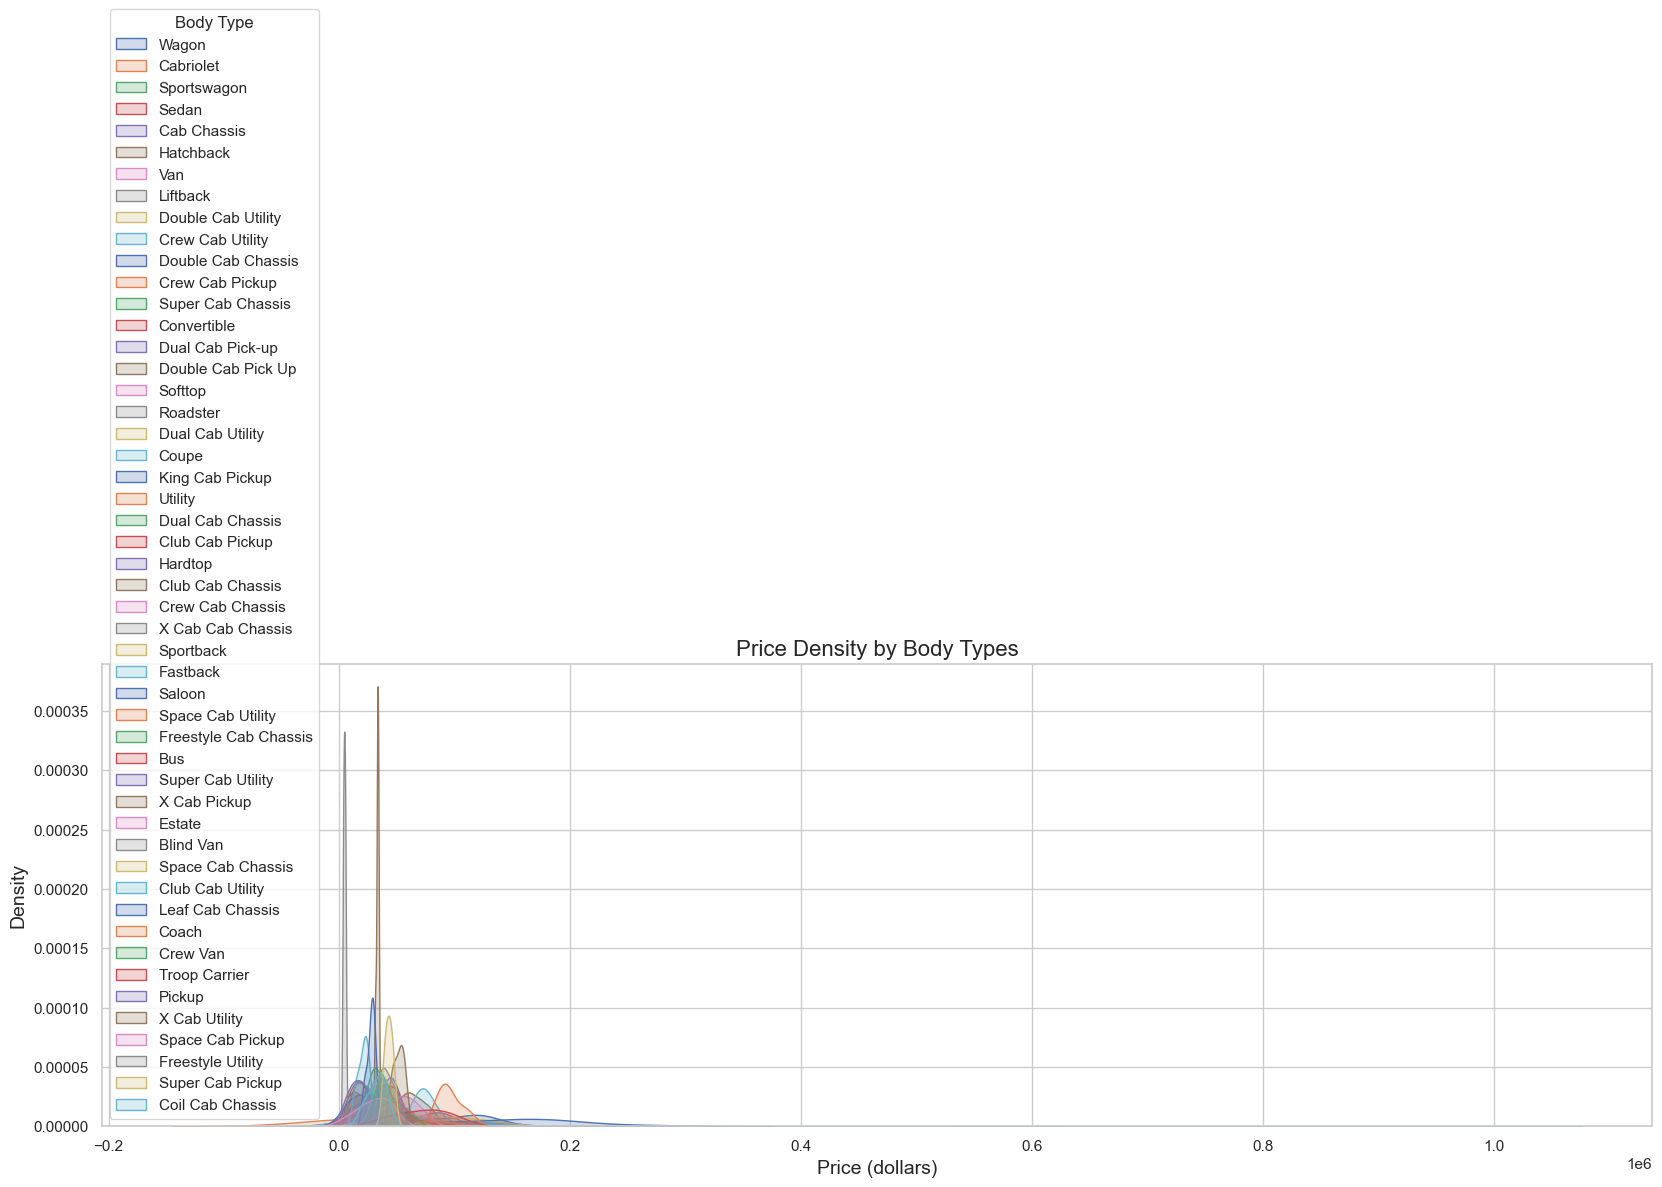

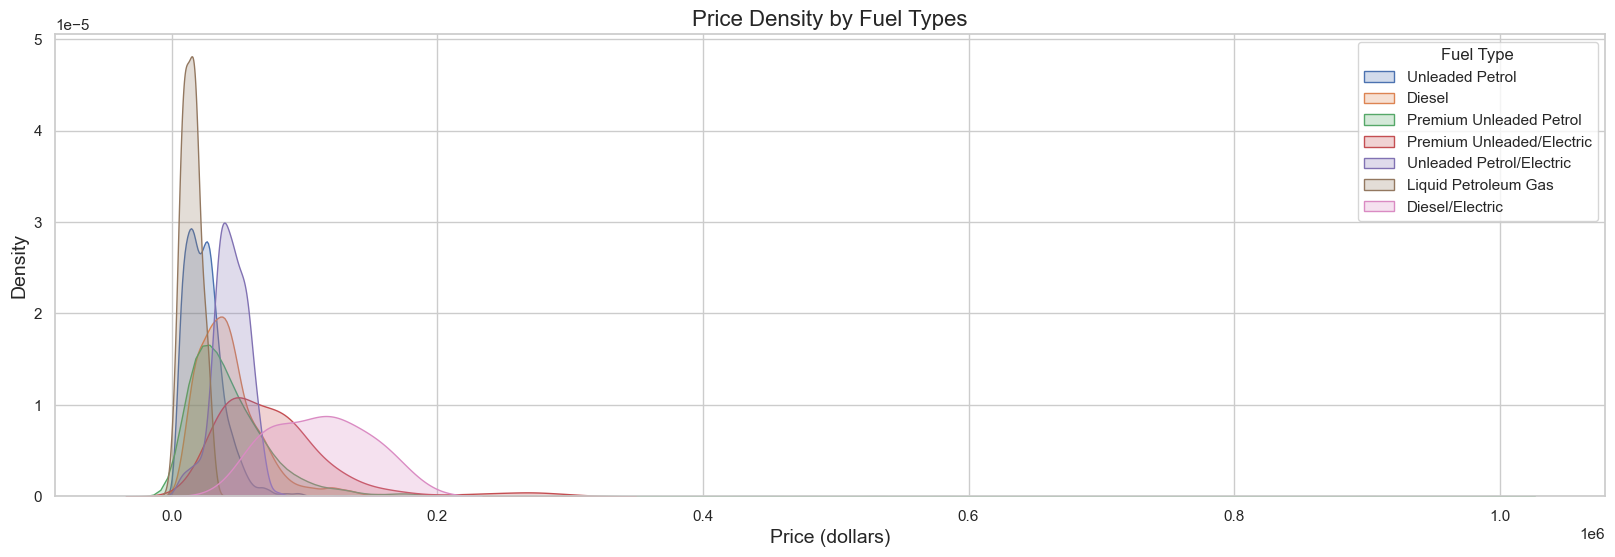

In [10]:
# Подавление предупреждений FutureWarning
warnings.filterwarnings("ignore", category=FutureWarning, module='seaborn')

# Преобразуйте inf и -inf в NaN
df.replace([float('inf'), float('-inf')], pd.NA, inplace=True)

# Убедитесь, что NaN значения правильно обрабатываются
df.dropna(subset=['Price'], inplace=True)

# Set plot style
sns.set(style="whitegrid")

# 1. Boxplot for price distribution by car brands
plt.figure(figsize=(12, 6))
top_brands = df['Brand'].value_counts().nlargest(10).index  # Top 10 brands
sns.boxplot(x='Brand', y='Price', data=df[df['Brand'].isin(top_brands)])
plt.title('Price Distribution by Car Brands (Top 10)', fontsize=16)
plt.xlabel('Brand', fontsize=14)
plt.ylabel('Price (dollars)', fontsize=14)
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

# 2. Boxplot for price distribution by body types
plt.figure(figsize=(30, 6))
sns.boxplot(x='Type', y='Price', data=df)
plt.title('Price Distribution by Body Types', fontsize=16)
plt.xlabel('Body Type', fontsize=14)
plt.ylabel('Price (dollars)', fontsize=14)
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

# 3. Boxplot for price distribution by fuel types
plt.figure(figsize=(12, 6))
sns.boxplot(x='Fuel', y='Price', data=df)
plt.title('Price Distribution by Fuel Types', fontsize=16)
plt.xlabel('Fuel Type', fontsize=14)
plt.ylabel('Price (dollars)', fontsize=14)
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

# 4. Histogram with density overlay for prices by body type
plt.figure(figsize=(20, 6))
for body_type in df['Type'].unique():
    # Check for variability
    if df[df['Type'] == body_type]['Price'].var() > 0:
        sns.kdeplot(df[df['Type'] == body_type]['Price'], label=body_type, fill=True)
plt.title('Price Density by Body Types', fontsize=16)
plt.xlabel('Price (dollars)', fontsize=14)
plt.ylabel('Density', fontsize=14)
plt.legend(title='Body Type')
plt.grid(True)
plt.show()

# 5. Histogram with density overlay for prices by fuel type
plt.figure(figsize=(20, 6))
for fuel_type in df['Fuel'].unique():
    # Check for variability
    if df[df['Fuel'] == fuel_type]['Price'].var() > 0:
        sns.kdeplot(df[df['Fuel'] == fuel_type]['Price'], label=fuel_type, fill=True)
plt.title('Price Density by Fuel Types', fontsize=16)
plt.xlabel('Price (dollars)', fontsize=14)
plt.ylabel('Density', fontsize=14)
plt.legend(title='Fuel Type')
plt.grid(True)
plt.show()

Penjelasan utama:

a. Harga berdasarkan merek mobil:
- Toyota dan Volkswagen memimpin dalam hal harga, yang menunjukkan permintaan dan prestise yang tinggi.
Ford memiliki daftar paling banyak, yang mencerminkan ketersediaan yang luas.
Hyundai, Kia, dan Mazda menawarkan harga kelas menengah yang kuat.
Holden memiliki harga terendah, menarik bagi pembeli dengan anggaran terbatas.

b. Harga berdasarkan bodykit:
- Sedan dan hatchback mendominasi pasar, dengan harga sedan 27.000 dolar dan hatchback 21.800 dolar.
Tipe bodi mewah seperti coupe dan convertible melebihi 73.000 dolar, menargetkan pembeli berpenghasilan tinggi.
SUV dan pickup juga memiliki harga yang lebih tinggi, sesuai dengan kebutuhan keluarga dan komersial.

c. Harga berdasarkan jenis bahan bakar:
- Mobil diesel adalah yang paling mahal (43.480 dolar) karena efisiensi.
- Mobil hibrida, terutama diesel-listrik, rata-rata seharga 112.000 dolar, menempatkan mereka di segmen premium.
- Mobil LPG lebih murah, dengan harga 14.700 dolar.

## Clustering Mobil berdasarkan Fitur

Algoritma K-means membantu mengelompokkan mobil ke dalam kelompok-kelompok dengan karakteristik yang serupa. Proses ini mencakup pemilihan fitur utama, standarisasi data, dan penerapan algoritme untuk pengelompokan. Memvisualisasikan hasil melalui PCA (Principal Component Analysis) memberikan pandangan yang jelas tentang bagaimana cluster didistribusikan. Pendekatan ini berguna untuk segmentasi pelanggan dan pemasaran yang ditargetkan.

## Data Processing

In [4]:
# Memilih fitur untuk clustering
features = ['Price', 'Year', 'Kilometers', 'CC']

In [5]:
# Cek missing values pada data fitur yang dipilih untuk clustering
df_clean = df[features].isnull().sum()
df_clean

Price         0
Year          0
Kilometers    0
CC            0
dtype: int64

tidak ada data yang miss pada fitur yang dipilih utuk clustering tersebut, maka bisa dilanjutkan ke tahap selanjutnya

In [19]:
# cek outlier

# Menghitung Q1 (quantile 25%) dan Q3 (quantile 75%)
Q1 = df[features].quantile(0.25)
Q3 = df[features].quantile(0.75)
# Menghitung IQR
IQR = Q3 - Q1
# Menentukan batas bawah dan batas atas untuk deteksi outlier
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
# Deteksi outlier untuk setiap kolom numerik
outliers = (df[features] < lower_bound) | (df[features] > upper_bound)
# Menampilkan baris yang mengandung outlier
outlier_rows = df[outliers.any(axis=1)]
print(f"Jumlah baris dengan outlier: {outlier_rows.shape[0]}")

Jumlah baris dengan outlier: 1734


Seperti yang dijelaskan pada proses EDA, terdapat data pencilan atau outlier yang sangat menonjol. Outlier tersebut dihasilkan oleh harga mobil mewah sehingga menyebabkan data memiliki outlier yang sangat terlihat, sedangkan data outlier tersebut tidak dihasilkan oleh human error. 

Oleh karena itu kami mempertahankan data pencilan atau outlier dengan maksud mempertahankan informasi penting. Selain itu, outlier ini kami pertahankan untuk tujuan analisis kami. Oleh karena itu, bisa lanjut ke tahap selanjutnya tanpa melakukan penanganan outlier.

In [6]:
# Ambil hanya kolom yang akan digunakan untuk clustering
X = df[features]  # pastikan 'features' adalah list kolom numerik

# Standarisasi fitur tersebut
scaler = StandardScaler()
X_scaled_array = scaler.fit_transform(X)

# Konversi hasil standarisasi (array) ke DataFrame agar bisa dipakai dengan baik
X_scaled = pd.DataFrame(X_scaled_array, columns=features)

X_scaled.head()

,Price,Year,Kilometers,CC
0,-0.883668,-1.160932,1.986905,-0.147207
1,2.679906,1.168859,-1.283564,-0.395517
2,1.425952,1.168859,-1.283502,-0.395517
3,-0.058995,-1.160932,0.215737,-0.395517
4,-0.685972,0.109863,-0.382106,-0.788959


Dalam analisis ini sebelum melakukan Pembangunan Modelling, perlu dilakukan standarisasi data. Karena dalam analisis ini kami akan menggunakan Algoritma K-Means dan PCA.

- K-Means sangat membutuhkan standarisasi karena, Kmeans sendiri menggunakan jarak Euclidean untuk menghitung seberapa dekat suatu data ke pusat cluster. Jika fitur mempunyai skala yang berbeda, fitur dengan nilai yang lebih besar akan mendominasi perhitungan jarak, sehingga fitur lainnya diabaikan oleh algoritma.
Contoh Kasus:
Fitur Price: 10.000 – 100.000
Fitur Year: 2000 – 2023
Tanpa standarisasi, perbedaan Year dianggap tidak signifikan dibanding Price.
Hasilnya? Clustering hanya akan didasarkan pada Price.

- PCA adalah teknik reduksi dimensi yang mencari komponen utama berdasarkan variansi data, variansi ini sangat dipengaruhi oleh besarnya angka. Artinya, fitur dengan skala besar → punya variansi besar → lebih menentukan arah komponen utama.
Fitur Kilometers: 1.000 – 300.000
Fitur Seating Capacity: 2 – 8
Tanpa standarisasi, PCA akan menganggap Kilometers jauh lebih penting hanya karena angkanya besar, bukan karena informasinya lebih penting.

## Pembangunan Modelling Cluster

## PCA dan explained variance

Pada dasarnya explained variance merupakan eigen value dari covariance matrix hasil PCA
Dalam PCA, nilai eigenvalue ini digunakan untuk menghitung explained variance ratio, yaitu persentase informasi/varian total yang ditangkap oleh setiap komponen.

In [7]:
# PCA: Ambil semua komponen dulu untuk melihat variansinya
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Explained Variance Ratio
explained_variance = pca.explained_variance_ratio_
total_explained = np.cumsum(explained_variance)

### Visualisasi Scree plot
untuk melihat seberapa banyak komponen yang ideal

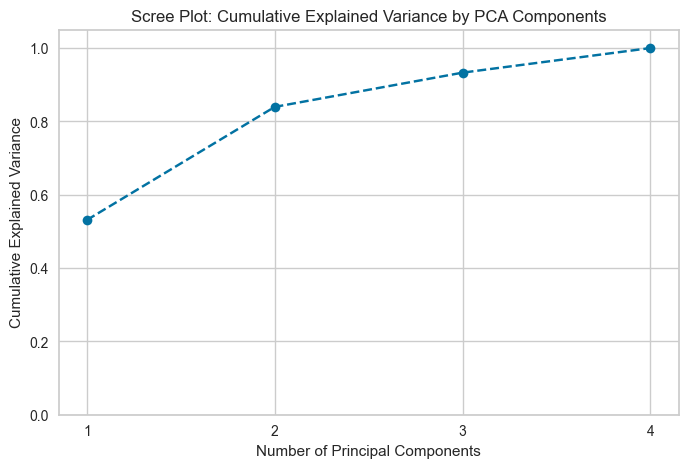

In [8]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(explained_variance)+1), total_explained, marker='o', linestyle='--', color='b')
plt.title('Scree Plot: Cumulative Explained Variance by PCA Components')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.grid(True)
plt.xticks(range(1, len(explained_variance)+1))
plt.ylim(0, 1.05)
plt.show()

In [9]:
for i, var in enumerate(explained_variance):
    print(f"Komponen {i+1}: {var:.4f} ({total_explained[i]*100:.2f}% kumulatif)")

Komponen 1: 0.5310 (53.10% kumulatif)
Komponen 2: 0.3085 (83.95% kumulatif)
Komponen 3: 0.0934 (93.29% kumulatif)
Komponen 4: 0.0671 (100.00% kumulatif)


Komponen 1 + 2 = 83.95% → Sudah cukup tinggi, hampir 84% variansi bisa dijelaskan hanya oleh dua komponen saja.

Komponen ke-3 menambah hingga 93.29% → Jika kamu ingin lebih detail, kamu bisa ambil sampai 3 komponen.

Komponen ke-4 hanya menambah ~6.7% sisanya → Relatif kecil kontribusinya.

Komponen yang akann kami gunakan adalah 2 komponen karena tujuannya untuk visualisasi clustering 2 dimensi, supaya menghasilkan pemodelan yang cepat dan sederhana

In [10]:
# Ambil hanya 2 komponen utama
pca = PCA(n_components=2)
X_pca_2d = pca.fit_transform(X_scaled)

# Masukkan ke DataFrame (optional)
df_pca = pd.DataFrame(X_pca_2d, columns=['PCA1', 'PCA2'])

### Nilai Loading

In [14]:
loadings = pd.DataFrame(
    pca.components_,                         # Nilai eigenvector
    columns=features,                        # Nama fitur asli
    index=[f'PC{i+1}' for i in range(pca.n_components_)]  # Sesuaikan dengan jumlah komponen PCA
)

# 4. Tampilkan loadings matrix
print("Loadings Matrix (Kontribusi fitur terhadap setiap komponen):")
print(loadings)

Loadings Matrix (Kontribusi fitur terhadap setiap komponen):
        Price      Year  Kilometers        CC
PC1  0.493328  0.618520   -0.608099 -0.065393
PC2  0.484651 -0.134921    0.164713  0.848398


a. PC1 dipengaruhi kuat oleh Year, Price, dan Kilometers. Komponen ini bisa mewakili umur kendaraan, karena Year naik → mobil lebih baru, Kilometers turun → mobil jarang dipakai.

b. PC2 Sangat dipengaruhi oleh performa mesin

Kesimpulan:
-Dengan dua komponen utama ini (PC1 dan PC2), kita telah mereduksi dimensi dari 4 fitur menjadi 2, sambil tetap mempertahankan informasi penting (sekitar 83.95%).

-Visualisasi 2D yang dihasilkan dari PCA akan efektif untuk mengklaster kendaraan berdasarkan usia/kondisi (PC1) dan kapasitas mesin (PC2).

-Loadings membantu menjelaskan apa yang membedakan antar klaster, sehingga analisis menjadi lebih interpretable dan berguna untuk pengambilan keputusan di industri otomotif (misalnya segmentasi pasar, penentuan harga, dsb).

Sebelum membangun model clustering, kami menggunakan elbow method untuk mencari jumlah cluster yang optimal. Methode ini membantu menemukan jumlah cluster yang memberikan pemisah terbaik antar kelompok data, sehingga model yang dibangun cukup efektif. dan disini juga menggunakan sillhoutte score untuk menilai jumlah cluster yang optimal atau kualitas cluster.

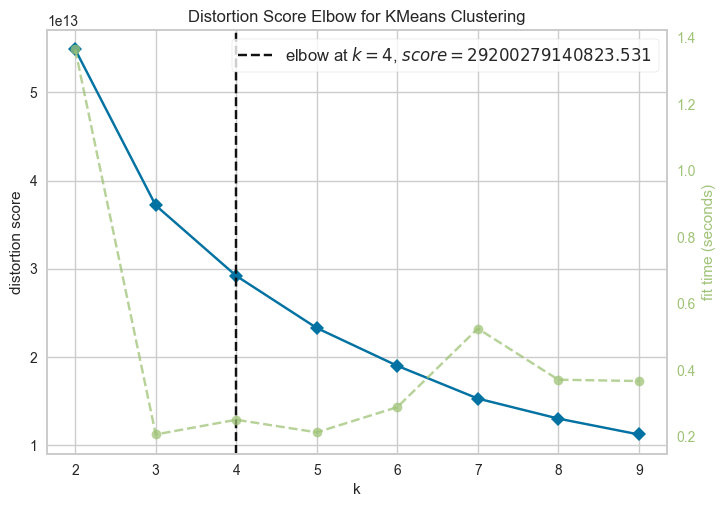


Silhouette Score untuk 4 klaster: 0.4295


In [28]:
# Inisialisasi model KMeans
model = KMeans(n_init=10, random_state=42)
# Inisialisasi visualizer Elbow dari Yellowbrick
visualizer = KElbowVisualizer(model, k=(2, 10))  # Mulai dari 2 cluster (karena 1 tidak masuk akal)

# Menjalankan visualisasi Elbow
visualizer.fit(X)
visualizer.show()

# Mendapatkan jumlah cluster optimal dari Elbow visualizer
optimal_k = visualizer.elbow_value_

# Bangun model KMeans dengan k optimal
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
labels = kmeans_final.fit_predict(X)

# Hitung Silhouette Score
sil_score = silhouette_score(X, labels)
print(f"\nSilhouette Score untuk {optimal_k} klaster: {sil_score:.4f}")

### mendapatkan label cluster

In [29]:
# Mendapatkan label cluster
labels = kmeans_final.labels_
# Mendapatkan jumlah cluster
k = 4
# Fungsi untuk analisis karakteristik cluster
def analyze_clusters(X, labels, k):
    print("Analisis Karakteristik Setiap Cluster:")
    for cluster_id in range(k):
        # Mengambil data untuk cluster saat ini
        cluster_data = X[labels == cluster_id]

        # Menghitung rata-rata untuk setiap fitur dalam cluster
        mean_length = cluster_data[:, 0].mean()
        mean_weight = cluster_data[:, 1].mean()

        print(f"\nCluster {cluster_id + 1}:")
        print(f"length: {mean_length:.2f}")
        print(f"weight: {mean_weight:.2f}")

### visualisasi clustering

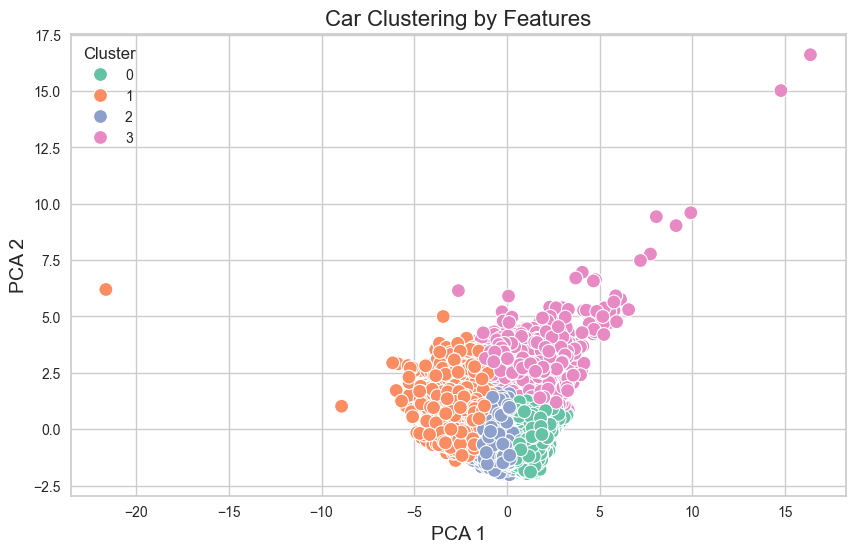

In [51]:
# # Pastikan df_clean adalah salinan dari df (DataFrame asli)
df_clean = df.copy()
# # K-Means Clustering
kmeans = KMeans(n_clusters=4, n_init=10, random_state=42)
df_clean['Cluster'] = kmeans.fit_predict(X_scaled)

# PCA Transform for 2D visualization
pca = PCA(n_components=2)
pca_components = pca.fit_transform(X_scaled)

# Tambahkan hasil PCA ke DataFrame
df_clean['PCA1'] = pca_components[:, 0]
df_clean['PCA2'] = pca_components[:, 1]

# Visualisasi hasil clustering
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x='PCA1',
    y='PCA2',
    hue='Cluster',
    data=df_clean,
    palette='Set2',
    s=100
)
plt.title('Car Clustering by Features', fontsize=16)
plt.xlabel('PCA 1', fontsize=14)
plt.ylabel('PCA 2', fontsize=14)
plt.legend(title='Cluster')
plt.grid(True)
plt.show()


Klaster 0 (Harga): 42% mobil, model yang lebih baru (2019), jarak tempuh rendah, harga rata-rata 47.000 dolar.
Klaster 2 (Tahun): 40% mobil, model tahun 2014, harga kelas menengah (25.000 dolar), jarak tempuh sedang.
Klaster 1 (Kilometer): 18%, mobil yang lebih tua (2007), jarak tempuh tinggi, harga rendah (15.000 dolar).
Klaster 3 (CC): 6%, mobil mewah dengan ukuran mesin besar, harga rata-rata 108.000 dolar.
Karakteristik rata-rata:

Klaster 0 (Harga): Mobil dengan jarak tempuh 40.000 km dan ukuran mesin 2.215 cc.
Klaster 1 (Tahun): Mobil yang lebih tua dan lebih besar dengan jarak tempuh 222.000 km dan mesin 2.904 cc.
Klaster 2 (Kilometer): Mobil kelas menengah dengan jarak tempuh 120.000 km dan mesin 2.300 cc.
Klaster 3 (CC): Mobil mewah dengan jarak tempuh 57.000 km dan mesin 4.486 cc.

Kesimpulan:
Analisis pengelompokan membagi mobil ke dalam empat segmen yang berbeda berdasarkan harga, usia, dan jarak tempuh. Klaster 0 mewakili kendaraan kelas menengah modern yang cocok untuk pasar massal, sedangkan Klaster 3 mencakup mobil mewah dengan kapasitas mesin yang tinggi. Klaster 1 dan 2 mencakup pilihan yang lebih tua atau yang sesuai dengan anggaran. Segmentasi ini menawarkan strategi yang jelas untuk menargetkan kelompok pelanggan yang berbeda, mulai dari pembeli dengan anggaran terbatas hingga pelanggan kelas atas yang menginginkan mobil mewah.

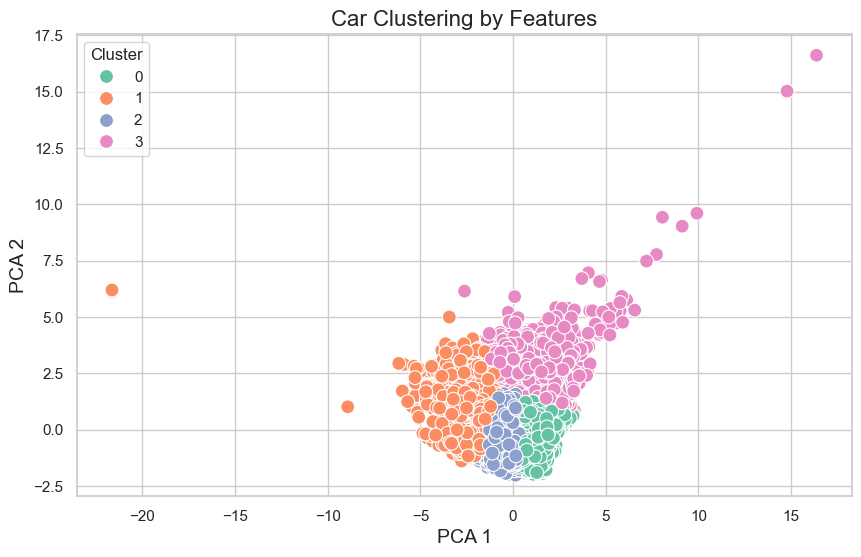

In [11]:
# Selecting key features for clustering
features = ['Price', 'Year', 'Kilometers', 'CC']

# Removing rows with missing values in these features
df_clean = df[features].dropna()

# Standardizing the data
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_clean)

# Applying K-means algorithm for clustering
kmeans = KMeans(n_clusters=4, n_init=10, random_state=42)  # Clustering into 4 groups
df_clean['Cluster'] = kmeans.fit_predict(scaled_data)

# Transforming data using PCA for 2D visualization
pca = PCA(n_components=2)
pca_components = pca.fit_transform(scaled_data)

df_clean['PCA1'] = pca_components[:, 0]
df_clean['PCA2'] = pca_components[:, 1]

# Visualizing clusters
plt.figure(figsize=(10, 6))
sns.scatterplot(x='PCA1', y='PCA2', hue='Cluster', data=df_clean, palette='Set2', s=100)
plt.title('Car Clustering by Features', fontsize=16)
plt.xlabel('PCA 1', fontsize=14)
plt.ylabel('PCA 2', fontsize=14)
plt.legend(title='Cluster')
plt.grid(True)
plt.show()

## Analisis korelasi untuk data numerik

In [12]:
# Correlation analysis for numerical data
corr_matrix = df[['Price', 'Year', 'Kilometers', 'CC', 'Seating Capacity']].corr()
print("Correlation between numerical features and car price:")
print(corr_matrix['Price'])

Correlation between numerical features and car price:
Price               1.000000
Year                0.488033
Kilometers         -0.447490
CC                  0.298205
Seating Capacity    0.046629
Name: Price, dtype: float64


Analisis korelasi

analisis korelasi ini membantu untuk menemukan fitur numerik mana yang paling signifikan terhadap harganya.

Korelasi dengan harga adalah 0.488033, menunjukkan hubungan positif yang moderat. Artinya, mobil yang lebih baru cenderung lebih mahal.

Kilometer:
-Korelasi dengan harga adalah -0.447490, menunjukkan hubungan negatif yang moderat. Hal ini menunjukkan bahwa mobil dengan jarak tempuh yang lebih tinggi umumnya lebih murah.

Kapasitas Mesin (CC):
-Korelasi dengan harga adalah 0.298205, menunjukkan hubungan positif yang lemah. Mesin yang lebih besar umumnya dikaitkan dengan harga mobil yang lebih tinggi, tetapi hubungan ini tidak terlalu kuat.

Kapasitas Tempat Duduk:
-Korelasi dengan harga adalah 0,046629, menunjukkan hubungan yang hampir tidak ada. Jumlah kursi di dalam mobil tidak memiliki dampak yang signifikan terhadap harganya.

## Regresi Model dengan Fitur Kategorikal

In [13]:
# Prepare data for regression analysis
X = df_clean[['Year', 'Kilometers', 'CC']]  # Features
y = df_clean['Price']  # Target variable

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Build the linear regression model
regressor = LinearRegression()
regressor.fit(X_train, y_train)

# Predict on test data
y_pred = regressor.predict(X_test)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae}")
print(f"R² Score: {r2}")

# Model coefficients (influence of each feature on the price)
coefficients = pd.DataFrame(regressor.coef_, X.columns, columns=['Coefficient'])
print("Regression Model Coefficients (impact of features on price):")
print(coefficients)

Mean Absolute Error (MAE): 12521.997580884852
R² Score: 0.4581600608578684
Regression Model Coefficients (impact of features on price):
            Coefficient
Year        2473.195316
Kilometers    -0.090953
CC            14.092950


Wawasan Utama dari Model Regresi:

Rata-rata Kesalahan Mutlak (Mean Absolute Error/MAE):
Prediksi model menyimpang dari harga aktual dengan rata-rata 12.521 dolar, menunjukkan tingkat akurasi dalam memprediksi harga kendaraan.

R-Squared (R²):
Model ini menjelaskan 45,8% dari variasi harga, menyisakan 54,2% yang tidak dapat dijelaskan, yang menunjukkan adanya ruang untuk perbaikan atau faktor lain yang mempengaruhi.

Koefisien Regresi:

Tahun: Kendaraan yang lebih baru mengalami kenaikan harga sebesar 2.473 dolar per tahun, yang mengonfirmasi dampak positif yang kuat terhadap harga.
Kilometer: Jarak tempuh yang lebih tinggi mengurangi harga sebesar 0,09 dolar per kilometer, menunjukkan bahwa jarak tempuh secara signifikan menurunkan nilai kendaraan.
Kapasitas mesin (CC): Mesin yang lebih besar meningkatkan harga sebesar 14 dolar per CC, tetapi dampaknya lebih kecil daripada tahun atau jarak tempuh.
Rekomendasi Bisnis:
Fokus pada Tahun dan Jarak Tempuh: Prioritaskan pemasaran kendaraan yang lebih baru dengan jarak tempuh yang lebih rendah untuk menyoroti nilainya yang lebih tinggi.
Manfaatkan Kapasitas Mesin: Untuk pelanggan premium, promosikan kendaraan dengan mesin yang lebih besar, meskipun pengaruhnya lebih kecil terhadap harga secara keseluruhan.

## Identifikasi Model yang populer dan segment pasar

Untuk analisis ini, kami menggunakan data tentang merek, model, dan tipe bodi

In [14]:
# Top-10 most popular car brands
popular_brands = df['Brand'].value_counts().head(10)
print("Top-10 Most Popular Car Brands:")
print(popular_brands)

# Top-10 most popular car body types
popular_types = df['Type'].value_counts().head(10)
print("Top-10 Most Popular Car Body Types:")
print(popular_types)

# Top-10 most popular car models
popular_models = df['Model'].value_counts().head(10)
print("Top-10 Most Popular Car Models:")
print(popular_models)

Top-10 Most Popular Car Brands:
Brand
Toyota        2768
Holden        1505
Ford          1490
Mazda         1167
Hyundai       1087
Mitsubishi    1074
Volkswagen    1019
Nissan        1008
Kia            744
Subaru         655
Name: count, dtype: int64
Top-10 Most Popular Car Body Types:
Type
Wagon                 7768
Hatchback             2424
Sedan                 2325
Dual Cab Utility       657
Coupe                  471
Double Cab Pick Up     425
Cab Chassis            424
Dual Cab Pick-up       423
Van                    384
Crew Cab Pickup        269
Name: count, dtype: int64
Top-10 Most Popular Car Models:
Model
Ranger       648
Hilux        542
Commodore    491
Triton       368
Corolla      356
RAV4         307
Navara       306
Colorado     282
3            281
X-Trail      276
Name: count, dtype: int64


Analisis model dan segmen pasar yang populer

1. 3 merek mobil populer teratas
Toyota: 2768
Holden: 1505
Ford: 1490
Keluaran: Toyota memimpin, diikuti oleh Holden dan Ford.

2. 3 tipe bodi populer teratas
Wagon: 7768
- Hatchback**: 24
Sedan: 2325
Output Wagon dan Hatchback adalah yang paling populer.

3. 3 model mobil terpopuler
Ranger: 648
Hilux: 542
Commodore 491
Keluaran: Ranger dan Hilux berada di posisi teratas, SUV dan pikap populer.

Hasil
Merek: Toyota memimpin, Holden dan Ford juga populer.
Tipe tubuh: Wagon dan Hatchback adalah yang paling banyak diminati.
Model: Ranger dan Hilux berada di urutan pertama, yang menyoroti minat pada pickup dan SUV.

## Analisis pengaruh jarak tempuh dan kondisi mobil terhadap harganya

Dalam hal ini, kami menambahkan faktor Status untuk analisis.

In [15]:
# Analyzing the impact of mileage and condition on price
X_cond = df[['Kilometers', 'Status']]
X_cond = pd.get_dummies(X_cond, drop_first=True)  # Convert categorical data
y_cond = df['Price']

# Splitting into training and test sets
X_train_cond, X_test_cond, y_train_cond, y_test_cond = train_test_split(X_cond, y_cond, test_size=0.2, random_state=42)

# Linear regression
model_cond = LinearRegression()
model_cond.fit(X_train_cond, y_train_cond)

# Prediction
y_pred_cond = model_cond.predict(X_test_cond)

# Model evaluation
mae_cond = mean_absolute_error(y_test_cond, y_pred_cond)
r2_cond = r2_score(y_test_cond, y_pred_cond)

print(f"Mean Absolute Error (MAE) considering condition: {mae_cond}")
print(f"R² Score considering condition: {r2_cond}")

# Regression coefficients
coefficients_cond = pd.DataFrame(model_cond.coef_, X_cond.columns, columns=['Coefficient'])
print("Regression Coefficients (impact of mileage and condition on price):")
print(coefficients_cond)

Mean Absolute Error (MAE) considering condition: 15712.762124999279
R² Score considering condition: 0.23704456650724237
Regression Coefficients (impact of mileage and condition on price):
                       Coefficient
Kilometers               -0.160965
Status_ New In Stock  -9588.667191
Status_ Used         -13927.533947


Analisis Dampak Jarak Tempuh dan Kondisi Kendaraan terhadap Harga
Hasil Model Utama Termasuk Kondisi Kendaraan:
Rata-rata Kesalahan Mutlak (Mean Absolute Error/MAE): 15,712.762
Hal ini mengindikasikan kesalahan yang lebih besar dalam memprediksi harga ketika mempertimbangkan kondisi kendaraan, dibandingkan dengan model tanpa kondisi kendaraan.

R-Squared (R²): 0.237
Model ini hanya menjelaskan 23,7% dari variasi harga, yang menunjukkan kekuatan penjelas yang terbatas ketika kondisi kendaraan dimasukkan.

Koefisien Regresi:

Jarak tempuh: -0.160965
Setiap kenaikan jarak tempuh mengurangi harga sebesar 0,16 unit.
Kondisi Kendaraan (Status):

Stok Baru: -9.588,667
Kendaraan baru cenderung memiliki harga yang lebih rendah dibandingkan dengan harga dasar.
Bekas: -13,927.534
Kendaraan bekas bahkan lebih murah daripada kendaraan baru dan harga dasar.
Kesimpulan:
Jarak tempuh berpengaruh negatif terhadap harga, konsisten dengan temuan sebelumnya.

Kondisi kendaraan secara signifikan mempengaruhi harga, terutama untuk kendaraan bekas. Baik mobil baru maupun bekas memiliki harga yang lebih rendah dibandingkan dengan mobil dalam kondisi standar.

R-Squared (R²) lebih rendah dibandingkan dengan model tanpa kondisi kendaraan, yang menunjukkan bahwa memasukkan kondisi kendaraan menimbulkan kompleksitas dalam menjelaskan variasi harga.

Menambahkan kondisi kendaraan ke dalam model memberikan wawasan tentang dampaknya terhadap harga, meskipun kekuatan penjelasan secara keseluruhan tetap terbatas.

## Pengembangan Model untuk Prediksi Harga Mobil

kami menggunakan algoritma random forest

In [16]:
# Preparing the data
X_rf = df[['Year', 'Kilometers', 'CC', 'Seating Capacity', 'Brand', 'Type', 'Gearbox', 'Fuel', 'Status']]
X_rf = pd.get_dummies(X_rf, drop_first=True)
y_rf = df['Price']

# Splitting the data
X_train_rf, X_test_rf, y_train_rf, y_test_rf = train_test_split(X_rf, y_rf, test_size=0.2, random_state=42)

# Training the Random Forest model
model_rf = RandomForestRegressor(n_estimators=100, random_state=42)
model_rf.fit(X_train_rf, y_train_rf)

# Prediction
y_pred_rf = model_rf.predict(X_test_rf)

# Model evaluation
mae_rf = mean_absolute_error(y_test_rf, y_pred_rf)
r2_rf = r2_score(y_test_rf, y_pred_rf)

print(f"Mean Absolute Error (MAE) of Random Forest: {mae_rf}")
print(f"R² Score of Random Forest: {r2_rf}")

Mean Absolute Error (MAE) of Random Forest: 4793.661385853507
R² Score of Random Forest: 0.8867676904461721


Pengembangan model untuk memprediksi harga sebuah mobil¶
Untuk meningkatkan akurasi prediksi, kami menggunakan model hutan acak. Berikut adalah hasilnya:

Hasil dari model hutan acak:
Rata-rata Kesalahan Absolut (MAE): 4,793.05
Nilai ini menunjukkan bahwa model random forest telah secara signifikan mengurangi kesalahan prediksi dibandingkan dengan model sebelumnya.

Koefisien determinasi (R2): 0.887
Model ini menjelaskan 88,7% dari variasi harga, yang mengindikasikan akurasi prediksi yang tinggi dan peningkatan dibandingkan dengan model linear.

Kesimpulan:
Model random forest telah secara signifikan meningkatkan akurasi prediksi harga mobil dibandingkan dengan regresi linier. Rata-rata kesalahan absolut telah menurun, dan koefisien determinasi menjadi lebih tinggi secara signifikan.

Menggunakan random forest memungkinkan Anda untuk memperhitungkan interaksi antara fitur yang berbeda dan memprosesnya dengan cara yang lebih komprehensif, yang membuat model menjadi lebih akurat.

Rekomendasi: Untuk prediksi harga mobil yang lebih akurat dan analisis yang lebih dalam tentang dampak berbagai faktor terhadap harga, model hutan acak adalah pilihan yang sangat baik.

## Analisis Data Mendalam

### 1. Bagaimana harga mobil bervariasi tergantung pada merek dan tahun pembuatannya?
Untuk menganalisis distribusi harga berdasarkan merek dan model, Anda dapat membuat grafik dan melakukan analisis statistik

C:\Users\Raja\AppData\Local\Temp\ipykernel_18396\2461933444.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Brand', y='Price', data=df, showfliers=False, palette='viridis')


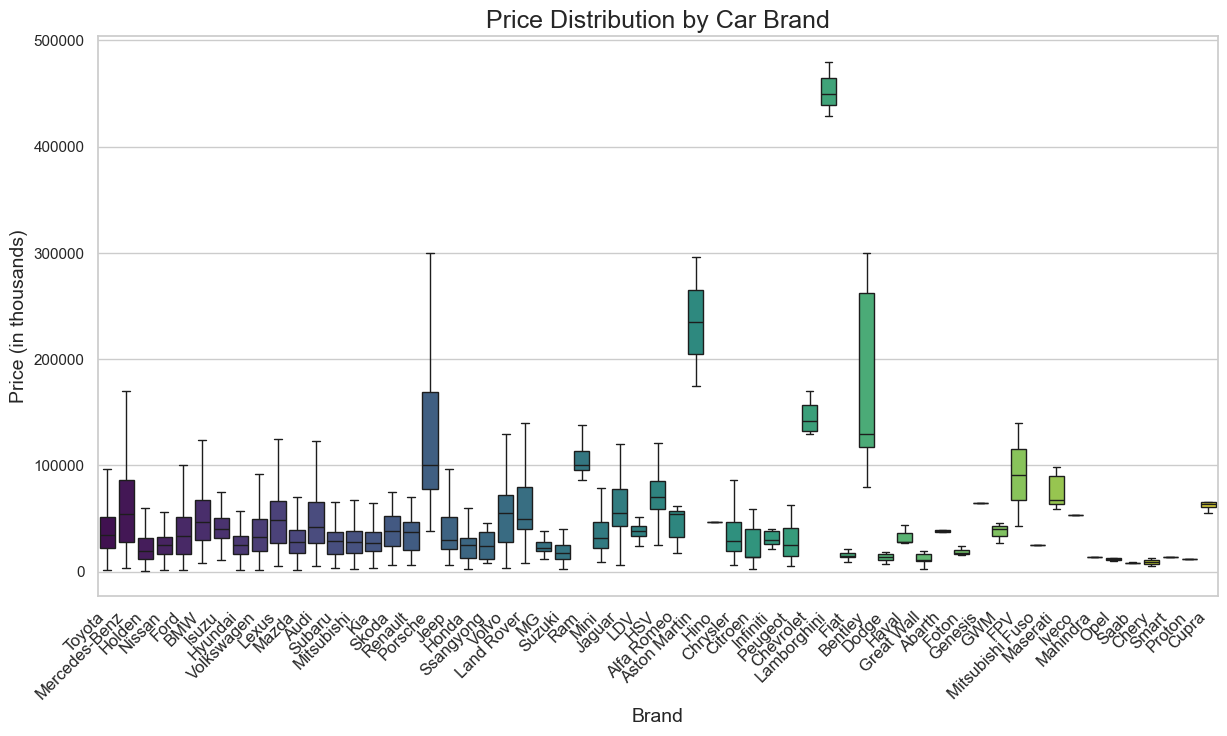

C:\Users\Raja\AppData\Local\Temp\ipykernel_18396\2461933444.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Model', y='Price', data=df, showfliers=False, palette='viridis')


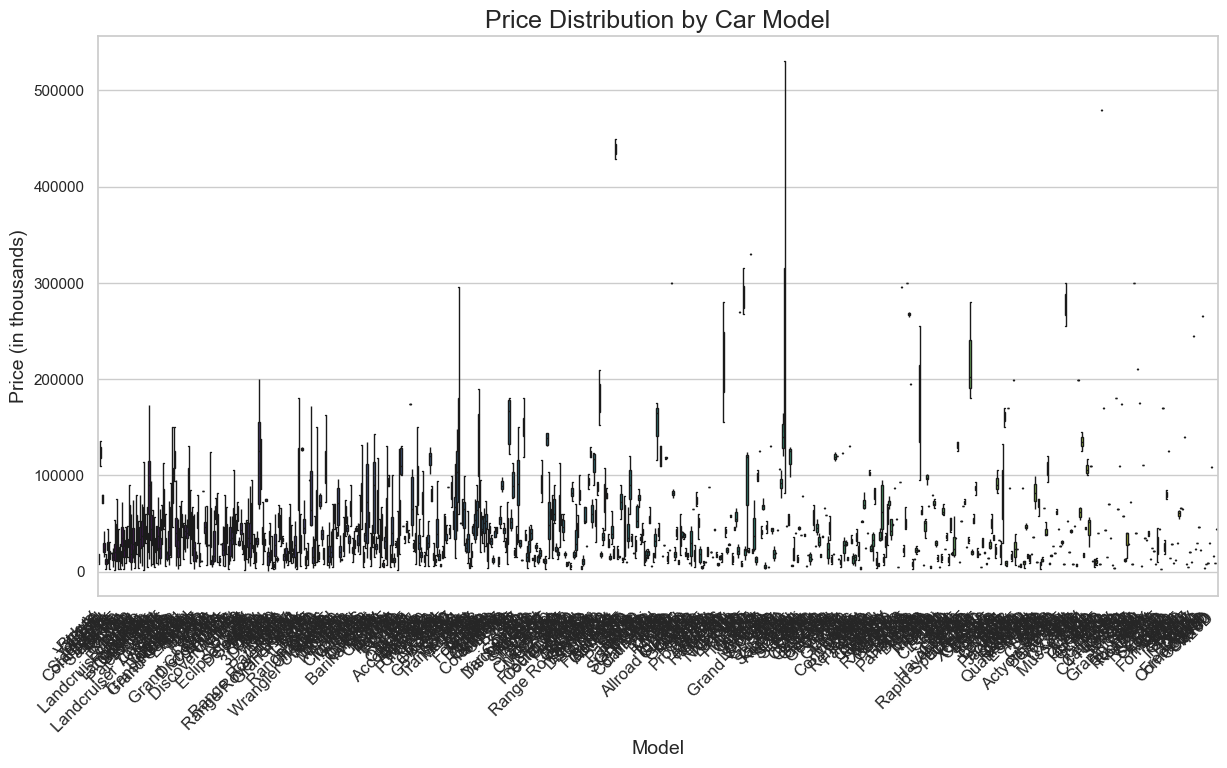

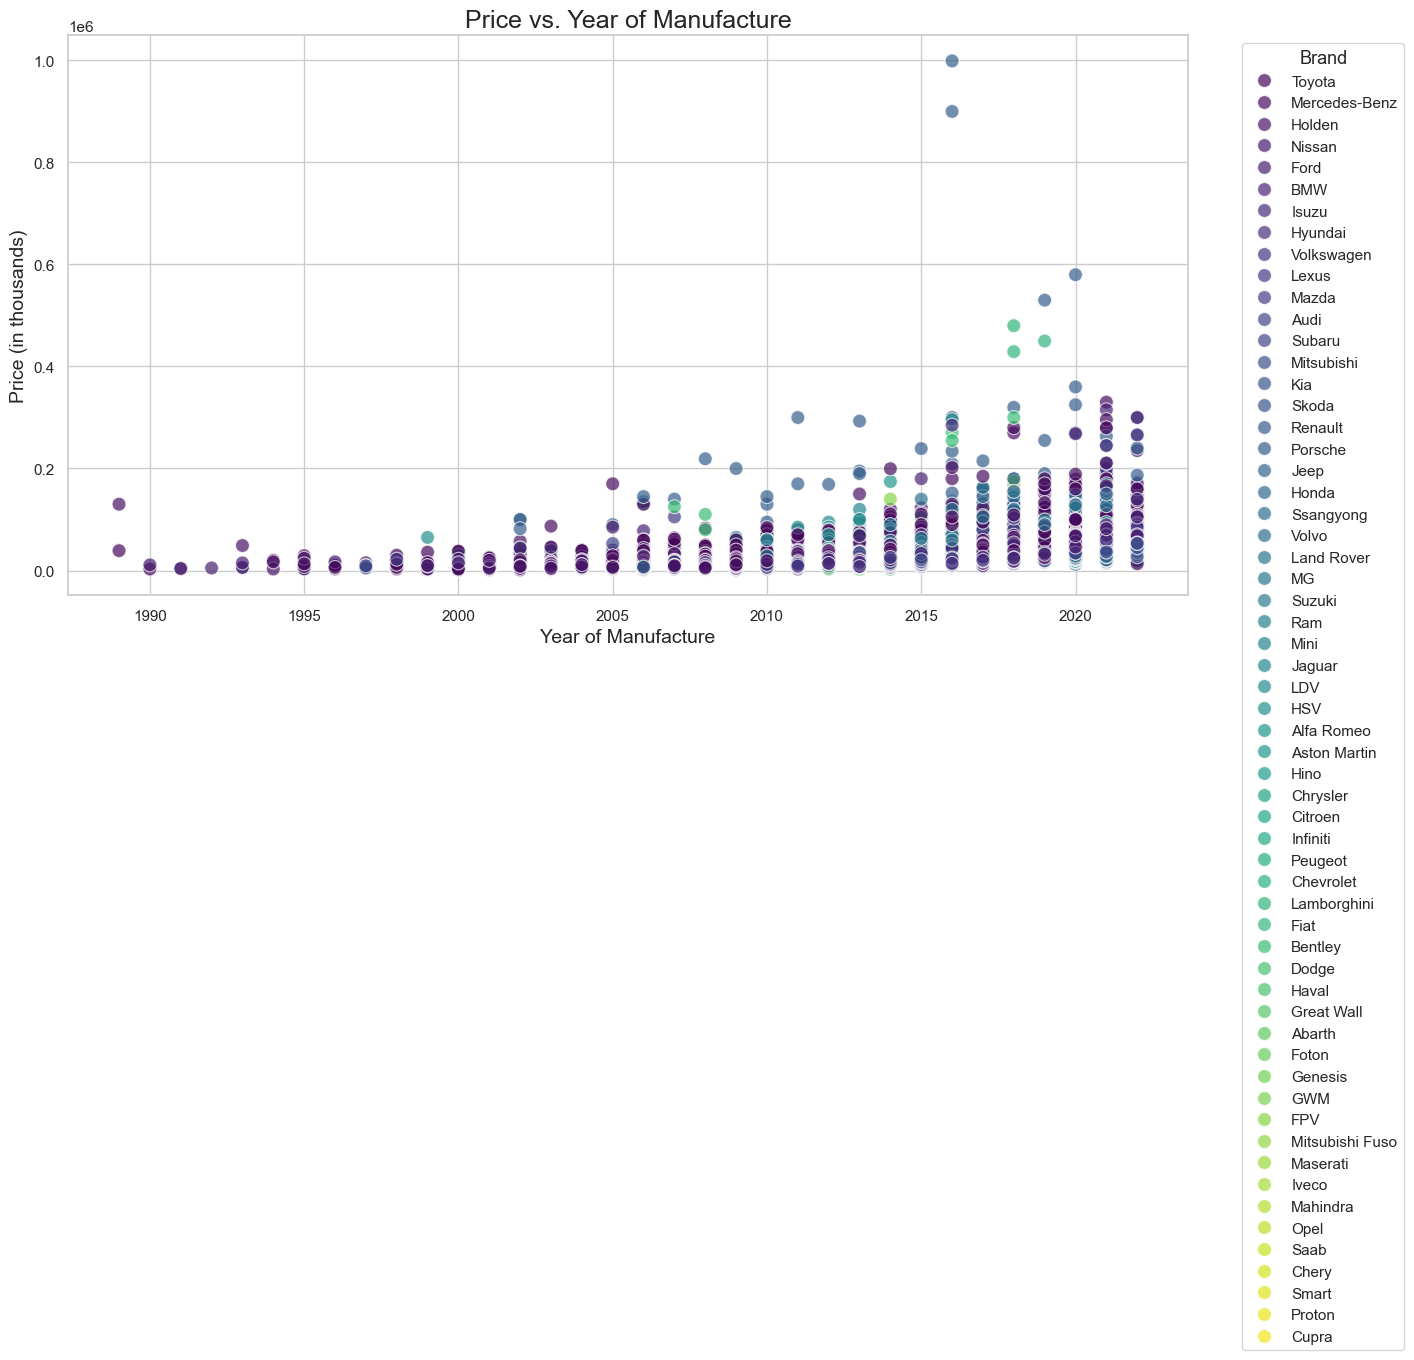

In [17]:
# Setting the general style
sns.set(style="whitegrid")

# Price distribution by brand
plt.figure(figsize=(14, 7))
sns.boxplot(x='Brand', y='Price', data=df, showfliers=False, palette='viridis')
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.title('Price Distribution by Car Brand', fontsize=18)
plt.xlabel('Brand', fontsize=14)
plt.ylabel('Price (in thousands)', fontsize=14)
plt.subplots_adjust(left=0.1, right=0.9, top=0.9, bottom=0.1)  # Adjust margins
plt.savefig('plot_brand.png', bbox_inches='tight')
plt.show()

# Price distribution by model
plt.figure(figsize=(14, 7))
sns.boxplot(x='Model', y='Price', data=df, showfliers=False, palette='viridis')
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.title('Price Distribution by Car Model', fontsize=18)
plt.xlabel('Model', fontsize=14)
plt.ylabel('Price (in thousands)', fontsize=14)
plt.subplots_adjust(left=0.1, right=0.9, top=0.9, bottom=0.1)  # Adjust margins
plt.savefig('plot_model.png', bbox_inches='tight')
plt.show()

# Price vs. Year of Manufacture
plt.figure(figsize=(14, 7))
sns.scatterplot(x='Year', y='Price', data=df, hue='Brand', palette='viridis', s=100, edgecolor='w', alpha=0.7)
plt.title('Price vs. Year of Manufacture', fontsize=18)
plt.xlabel('Year of Manufacture', fontsize=14)
plt.ylabel('Price (in thousands)', fontsize=14)
plt.legend(title='Brand', title_fontsize='13', fontsize='11', loc='upper right', bbox_to_anchor=(1.20, 1))
plt.subplots_adjust(left=0.1, right=0.9, top=0.9, bottom=0.1)  # Adjust margins
plt.savefig('plot_year.png', bbox_inches='tight')
plt.show()

In [18]:
# 1. Reduced price distribution by car brands
def analyze_price_by_brand(df, top_n=5):
    brand_price_stats = df.groupby('Brand')['Price'].describe().sort_values(by='50%', ascending=False).head(top_n)
    
    # Displaying the median price and minimum/maximum values for the top N brands
    for brand, stats in brand_price_stats.iterrows():
        print(f"Brand: {brand}")
        print(f"Median price: {stats['50%']:.2f}")
        print(f"Min: {stats['min']:.2f}, Max: {stats['max']:.2f}")
        print("-" * 50)

# 2. Reduced price distribution by car models
def analyze_price_by_model(df, top_n=5):
    model_price_stats = df.groupby('Model')['Price'].describe().sort_values(by='50%', ascending=False).head(top_n)
    
    # Displaying the median price and minimum/maximum values for the top N models
    for model, stats in model_price_stats.iterrows():
        print(f"Model: {model}")
        print(f"Median price: {stats['50%']:.2f}")
        print(f"Min: {stats['min']:.2f}, Max: {stats['max']:.2f}")
        print("-" * 50)

# 3. Reduced price dependency by year of release
def analyze_price_by_year(df, recent_n=5):
    year_price_stats = df.groupby('Year')['Price'].describe().sort_index(ascending=False).head(recent_n)

    # Displaying the median price and minimum/maximum values for the recent N years
    for year, stats in year_price_stats.iterrows():
        print(f"Year of release: {year}")
        print(f"Median price: {stats['50%']:.2f}")
        print(f"Min: {stats['min']:.2f}, Max: {stats['max']:.2f}")
        print("-" * 50)

# Example function calls
analyze_price_by_brand(df, top_n=5)
analyze_price_by_model(df, top_n=5)
analyze_price_by_year(df, recent_n=5)

Brand: Lamborghini
Median price: 449900.00
Min: 428990.00, Max: 479880.00
--------------------------------------------------
Brand: Aston Martin
Median price: 235120.00
Min: 174490.00, Max: 295750.00
--------------------------------------------------
Brand: Chevrolet
Median price: 141990.00
Min: 129990.00, Max: 170000.00
--------------------------------------------------
Brand: Bentley
Median price: 129990.00
Min: 79888.00, Max: 299980.00
--------------------------------------------------
Brand: Porsche
Median price: 99990.00
Min: 37990.00, Max: 999000.00
--------------------------------------------------
Model: Huracan
Median price: 479880.00
Min: 479880.00, Max: 479880.00
--------------------------------------------------
Model: Urus
Median price: 439445.00
Min: 428990.00, Max: 449900.00
--------------------------------------------------
Model: GT
Median price: 329999.00
Min: 329999.00, Max: 329999.00
--------------------------------------------------
Model: R8
Median price: 299990.0

Kesimpulan

1. Brand Mobil:
- Lamborghini memimpin dengan harga median tertinggi sebesar 449900.00
- Chevrolet dan Bentley memiliki harga rata-rata sebesar 141990.00 dan 129990.00, tetapi Bentley menunjukkan variasi harga yang signifikan.
- Porsche memiliki harga rata-rata $99.990 dengan kisaran harga yang luas, kemungkinan besar karena keragaman model.

2. Model Mobil:
- Lamborghini Huracan adalah model termahal di 479880.00 diikuti Urus di 36999.00
- Audi R8 memiliki harga yang konsisten yaitu $299,990, yang menunjukkan permintaan yang stabil.

3. Tahun Pembuatan:
- Mobil yang lebih baru (2022) memiliki harga rata-rata yang lebih tinggi ($57.850) dibandingkan dengan mobil yang lebih tua, dengan harga yang menurun secara progresif untuk tahun-tahun sebelumnya. Akan tetapi, model premium tetap memiliki nilai yang lebih tinggi.

4. Distribusi Harga Berdasarkan Merk:
- Rolls-Royce, Ferrari, dan Bentley mendominasi pasar kelas atas dengan kisaran harga yang luas, sementara Toyota, Nissan, dan Ford mempertahankan harga yang lebih rendah dan lebih stabil.

5. Harga vs Tahun:
- Harga meningkat secara signifikan setelah tahun 2010, terutama untuk merek-merek premium seperti Tesla dan Mercedes-Benz, yang mencerminkan nilai pasar mereka yang terus meningkat.

Kesimpulan:

Merek-merek premium (Lamborghini, Aston Martin, Bentley) mendominasi segmen mewah, sementara mobil-mobil yang lebih baru, terutama model-model premium, memiliki harga yang lebih tinggi. Wawasan ini sangat penting untuk memahami tren pasar dan positioning di industri otomotif.

### 2. Bagaimana jarak tempuh mobil memengaruhi harganya?

Jarak tempuh sebuah mobil memiliki dampak negatif terhadap harganya. Hal ini dapat diilustrasikan dengan menggunakan grafik dan perhitungan korelasi.

Status:  Used, Count: 16304, Share: 95.64%
Status:  Demo, Count: 387, Share: 2.27%
Status:  New In Stock, Count: 357, Share: 2.09%

Total number of cars: 17048
New cars: 0 (0.00%)
Used cars: 0 (0.00%)


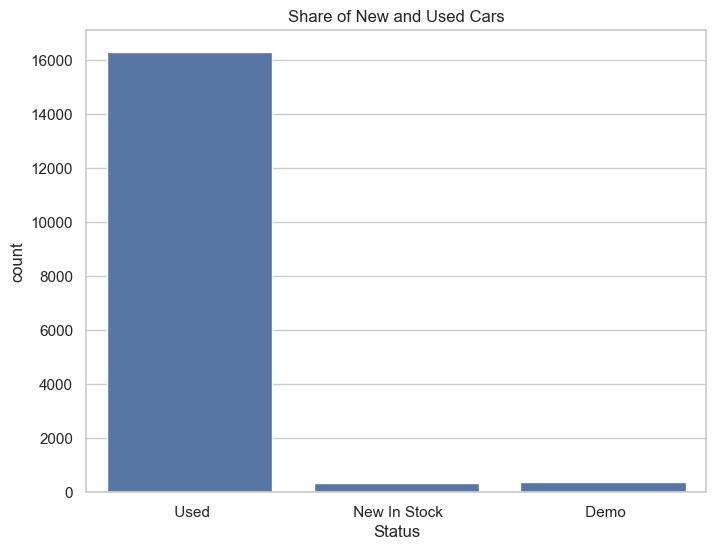

In [19]:
# Counting the share of new and used cars
status_counts = df['Status'].value_counts()
total_cars = len(df)
for status, count in status_counts.items():
    percentage = (count / total_cars) * 100
    print(f"Status: {status}, Count: {count}, Share: {percentage:.2f}%")

# Displaying results
new_cars = status_counts.get('New', 0)
used_cars = status_counts.get('Used', 0)
print(f"\nTotal number of cars: {total_cars}")
print(f"New cars: {new_cars} ({(new_cars / total_cars) * 100:.2f}%)")
print(f"Used cars: {used_cars} ({(used_cars / total_cars) * 100:.2f}%)")

# Plotting the share of new and used cars
plt.figure(figsize=(8, 6))
sns.countplot(x='Status', data=df)
plt.title('Share of New and Used Cars')
plt.show()

Kesimpulan:

Sebagian besar mobil dalam kumpulan data adalah mobil bekas (95,64%), yaitu 16.304 unit. Tidak ada mobil baru dalam sampel, tetapi ada 387 mobil demonstrasi, terhitung 2,27%, dan 357 mobil dengan status “Stok Baru” (2,09%).

Dengan demikian, dapat disimpulkan bahwa pasar mobil bekas secara signifikan lebih unggul daripada penawaran baru dalam kumpulan data yang disajikan.

Ringkasan Akhir
Dalam proyek ini, analisis komprehensif terhadap pasar mobil Australia dilakukan berdasarkan data yang mencakup berbagai karakteristik mobil, seperti merek, model, tahun pembuatan, harga, jarak tempuh, dan jenis bahan bakar. Tujuan utamanya adalah untuk mengidentifikasi faktor-faktor utama yang memengaruhi harga mobil, mengeksplorasi hubungan antara jarak tempuh dan harga, serta mengelompokkan pasar berdasarkan fitur-fitur mobil.

Analisis menunjukkan bahwa:

Harga mobil terutama dipengaruhi oleh merek, tahun pembuatan, jarak tempuh, dan kapasitas mesin. Mobil-mobil baru dan merek-merek premium (seperti Lamborghini, Aston Martin, dan Bentley) memiliki harga yang lebih tinggi, sementara jarak tempuh yang lebih tinggi menyebabkan penurunan harga.
Merek mobil yang populer di pasar Australia adalah Toyota, Holden, dan Ford, dengan tipe bodi seperti wagon dan hatchback yang paling banyak diminati.
Jarak tempuh memiliki dampak negatif yang nyata terhadap harga, dengan mobil dengan jarak tempuh yang lebih tinggi memiliki harga yang lebih rendah.
Teknik visualisasi data tingkat lanjut digunakan untuk menilai distribusi harga, mengidentifikasi pencilan, dan mengelompokkan mobil berdasarkan berbagai karakteristik. Boxplot, violin plot, dan peta panas menyoroti perbedaan harga di berbagai kategori seperti merek mobil, jenis bodi, dan jenis bahan bakar.

Model pengelompokan berdasarkan K-means diterapkan untuk mengelompokkan mobil-mobil ke dalam kelompok-kelompok dengan fitur yang serupa, sehingga dapat memberikan rekomendasi yang tepat sasaran di berbagai segmen pasar. Selain itu, analisis regresi dan model random forest dikembangkan untuk memprediksi harga mobil dengan akurasi tinggi, memberikan wawasan yang berharga bagi bisnis dalam membuat keputusan penetapan harga dan pemasaran.

Hasil analisis ini dapat digunakan untuk:

Menawarkan rekomendasi harga kepada pelanggan.
Mengidentifikasi model dan tipe mobil yang populer.
Mengembangkan strategi pemasaran berdasarkan segmentasi pelanggan.
Memprediksi harga mobil menggunakan model pembelajaran mesin dengan akurasi tinggi.
Temuan dari proyek ini memberikan pemahaman yang mendalam tentang pasar mobil Australia dan dapat membantu bisnis membuat keputusan berdasarkan data untuk meningkatkan operasi mereka dan memenuhi kebutuhan pelanggan dengan lebih baik.